# Setup

## Imports

In [1]:
# matplotlib
import matplotlib as mpl
from matplotlib.axes import Axes
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
from matplotlib.text import Text
from matplotlib.ticker import FixedLocator, MultipleLocator, MaxNLocator
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# others
import airr
import colorspacious as cs
import numpy as np
import pandas as pd
import seaborn as sns
from tabulate import tabulate

# add repertoire_zoo
import sys
pkg_path = "/mnt/md0/s236922/cowell-lab/repertoire_zoo/"
sys.path.append(pkg_path)
import repertoire_zoo.bird as br
import repertoire_zoo.giraffe as gr


/home/s236922/apps/miniconda3/envs/zoo/lib/python3.13/site-packages/airr/schema.py:10: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream


## Helper Functions

In [2]:
# for heatmaps
def norm_cols(matrix, norm_type='difference'):
    control_values = matrix.iloc[0, :]  # take first column as control
    if norm_type == 'fc':
        return (matrix.sub(control_values, axis=1)).div(control_values, axis=1)
    if norm_type == 'l2fc':
        return np.log2(matrix.div(control_values, axis=1)) # log2fc
    if norm_type == 'difference':
        return matrix.sub(control_values, axis=1)
    return matrix

# for heatmaps
def make_annotation_mat(matrix, standardized_matrix, round_mat=2, round_std_mat=2):
    # Now round and convert to string
    return matrix.round(round_mat).astype(str) + '\n(' + standardized_matrix.round(round_std_mat).astype(str) +')'

def add_N_to_legend(ax, groups_tuple):
    condition_counts = {e[1] : len(e[2]) for e in groups_tuple}
    handles, lables = ax.get_legend_handles_labels()
    new_labels = [f'{condition}, N={int(condition_counts[condition])}' for condition in lables]
    ax.legend(handles, new_labels, title='Group', loc='center left', bbox_to_anchor=(1, 0.5))

def add_N_to_xaxis(ax, groups_tuple):
    condition_counts = {e[1] : len(e[2]) for e in groups_tuple}
    labels = ax.get_xticklabels()
    new_labels = [Text(l.get_position()[0], l.get_position()[1], f'{l.get_text()}\nN={int(condition_counts[l.get_text()])}') for l in labels]
    ax.set_xticklabels(new_labels)

def add_N_to_yaxis(ax, groups_tuple):
    condition_counts = {e[1] : len(e[2]) for e in groups_tuple}
    labels = ax.get_yticklabels()
    new_labels = [Text(l.get_position()[0], l.get_position()[1], f'{l.get_text()}\nN={int(condition_counts[l.get_text()])}') for l in labels]
    ax.set_xticklabels(new_labels)



## Setup Directories/Read in Data

In [3]:
# Define project/job uuid
project_id = 'aa4b61e3-2809-4a47-bcf5-d09a82618851' # project uuid
job_id = '78808056-1d0d-455d-8845-65945c10f336-007' # job uuid

# Define data directories
data_dir = '/mnt/md0/Projects/MonsonLab/RIS/' #/path/to/data/directory/
repcalc_dir = data_dir + 'vdjserver/'+job_id+'/'
analysis_dir = data_dir + 'analysis/'
fig_dir = analysis_dir + 'figures/'

# Read in repertoire and repertoire group info
# The default name (repertoires.airr.json) is being used, but custom airr.json files can
# be used for defining repertoires and repertoire groups. 
repertoires_airr_json_filename = 'repertoires.airr.json'
sample_info_df = br.read_repertoire_info_airr(repcalc_dir + repertoires_airr_json_filename)
repertoire_group_df = br.read_repertoire_group_info_airr(repcalc_dir + repertoires_airr_json_filename)
data = airr.read_airr(repcalc_dir + repertoires_airr_json_filename)

# pull out repertoires and names
groups_of_interest = [ 'Healthy', 'CIS', 'RIS' ] # insert groups to compare (to compare all replace `...` with `None`)

if groups_of_interest == [None]:
    repertoire_groups_temp = { obj['repertoire_group_id'] : obj for obj in data['RepertoireGroup'] }
else:
    repertoire_groups_temp = { obj['repertoire_group_id'] : obj for obj in data['RepertoireGroup'] if obj['repertoire_group_name'] in groups_of_interest }
repertoires = { obj['repertoire_id'] : obj for obj in data['Repertoire']}

order_map = {name: idx for idx, name in enumerate(groups_of_interest)}
repertoire_groups = dict(sorted(
    repertoire_groups_temp.items(),
    key=lambda item: order_map.get(item[1]['repertoire_group_name'], len(groups_of_interest))
))

# make groups tuple
groups_tuple = [
    (
        repertoire_groups[rep_group_id]['repertoire_group_id'],
        repertoire_groups[rep_group_id]['repertoire_group_name'],
        [reps.get('repertoire_id') for reps in repertoire_groups[rep_group_id]['repertoires']]
    ) for rep_group_id in repertoire_groups
]

# identify control group(s) to compare against
control_group_names = [ 'Healthy' ] # insert control groups (for no control replace `...` with `None`)

for i, rep_group_id in enumerate(repertoire_groups):
    print(rep_group_id, i, repertoire_groups[rep_group_id]['repertoire_group_name'])

condition_counts = {e[1] : e[2] for e in groups_tuple}

Total Number of Repertoire Groups:  3
2731314e-38ee-4e05-93cd-cad896635705 0 Healthy
04d501f6-092a-4155-a150-853bd49d5879 1 CIS
141a3f4b-d582-45c3-9798-047b60c2682c 2 RIS


## Colormaps

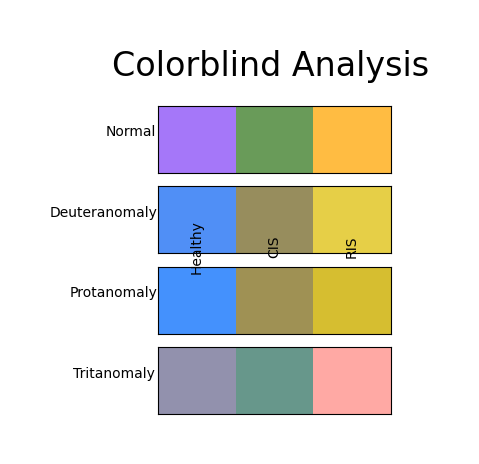

In [4]:
# set hue order (use condition names)
# By default the hue_order will be the same as the groups of interest. 
# If this is different, redfine `hue_order` as a list of groups from `groups_of_interest`
hue_order = groups_of_interest

cmap = mpl.colormaps['nipy_spectral'] # gist_rainbow
cmin = 0.0
cmax = 1.0

def generate_colormap(base_colors, all_names=None, n_shades=7, min_light=0, max_light=0.7):
    """
    Generate a dictionary of colors where each base color has n_shades variants
    going from dark to light, excluding white.

    Parameters
    ----------
    base_colors : dict
        Mapping of base condition name to base color (e.g., {'A': 'red', 'B': 'blue'}).
    n_shades : int
        Number of shades per base color.
    min_light : float
        Minimum lightness factor (0 = black, 1 = white).
    max_light : float
        Maximum lightness factor (0 = black, 1 = white).

    Returns
    -------
    dict : {condition_name: hex_color}
    """
    cmap_dict = {}

    for i, base in enumerate(base_colors):
        base_rgb = np.array(mcolors.to_rgb(base))
        for ii, factor in enumerate(np.linspace(min_light, max_light, n_shades)):
            # base_rgb * (1-factor) -> responsible for color being removed
            # np.ones(3) * factor -> responsible for the color interpolating to white
            shade_rgb = base_rgb * (1-factor) + (np.ones(3) * factor)
            
            cmap_dict[f"{all_names[i*n_shades+ii]}"] = mcolors.to_hex(shade_rgb)

    return cmap_dict

def show_colormap(color_cmap, ax=None, xtick_labels=True, xtick_height=-0.3):
    """
    Display colors associated in a color_cmap dictionary.

    Parameters
    ----------
    color_cmap : dict
        Dictionary mapping labels to color values (e.g., {'A': 'red', 'B': '#00FF00'}).
    """
    labels = list(color_cmap.keys())
    colors = list(color_cmap.values())

    # Create a figure
    if ax is None:
        fig, ax = plt.subplots(figsize=(len(labels), 1))
    else:
        fig = ax.get_figure()

    for i, color in enumerate(colors):
        ax.add_patch(plt.Rectangle((i, 0), 1, 1, color=color))
        if xtick_labels: ax.text(i + 0.5, xtick_height, labels[i], ha='center', va='center', fontsize=10, rotation=90)

    ax.set_xlim(0, len(colors))
    ax.set_ylim(0, 1)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_xticks([])
    ax.set_yticks([])

    return fig, ax


# V
v_genes = br.load_gene_usage_group_data(
    repcalc_dir=repcalc_dir,
    groups=groups_tuple,
    processing_stage='igblast.makedb.gene.clone',
    call_type='v_call',
    level='gene'
)['gene'].unique()
v_genes_cmap = {
    v_gene : cmap(np.linspace(cmin,cmax,len(v_genes))[i])
    for i, v_gene in enumerate(v_genes)
}

v_subgroups = br.load_gene_usage_group_data(
    repcalc_dir=repcalc_dir,
    groups=groups_tuple,
    processing_stage='igblast.makedb.gene.clone',
    call_type='v_call',
    level='subgroup'
)['gene'].unique()
v_subgroup_cmap = {
    v_subgroup : cmap(np.linspace(cmin,cmax,len(v_subgroups))[i])
    for i, v_subgroup in enumerate(v_subgroups)
}

# J
j_genes = br.load_gene_usage_group_data(
    repcalc_dir=repcalc_dir,
    groups=groups_tuple,
    processing_stage='igblast.makedb.gene.clone',
    call_type='j_call',
    level='gene'
)['gene'].unique()
j_genes_cmap = {
    j_gene : cmap(np.linspace(cmin,cmax,len(j_genes))[i])
    for i, j_gene in enumerate(j_genes)
}

j_subgroups = br.load_gene_usage_group_data(
    repcalc_dir=repcalc_dir,
    groups=groups_tuple,
    processing_stage='igblast.makedb.gene.clone',
    call_type='j_call',
    level='subgroup'
)['gene'].unique()
j_subgroup_cmap = {
    j_subgroup : cmap(np.linspace(cmin,cmax,len(j_subgroups))[i])
    for i, j_subgroup in enumerate(j_subgroups)
}

## cond_cmap
conds = br.load_and_prepare_data_junction_aa(
    repcalc_dir=repcalc_dir,
    groups=groups_tuple,
    processing_stage='.igblast.makedb.allele.clone.group.',
    call_type='junction_aa_length'
)['condition'].unique()

# Colorblind safe colors and colorblind analysis
# number of colors = number of base groups to compare
base_colors = ['#A577F9', '#699B59', '#FFBC42', '#086788', '#D36135']
cond_cmap = {
    cond : base_colors[i]
    for i, cond in enumerate(conds)
}

names = [cond[1] for cond in groups_tuple]

deuteranomaly_simulated_cmap = cs.cspace_convert(
    [mcolors.to_rgb(e) for e in cond_cmap.values()], 
    start = {
        "name": "sRGB1+CVD",
        "cvd_type": "deuteranomaly",
        "severity": 100
    },
    end = "sRGB1"
)

protanomaly_simulated_cmap = cs.cspace_convert(
    [mcolors.to_rgb(e) for e in cond_cmap.values()], 
    start = {
        "name": "sRGB1+CVD",
        "cvd_type": "protanomaly",
        "severity": 100
    },
    end = "sRGB1"
)

tritanomaly_simulated_cmap = cs.cspace_convert(
    [mcolors.to_rgb(e) for e in cond_cmap.values()], 
    start = {
        "name": "sRGB1+CVD",
        "cvd_type": "tritanomaly",
        "severity": 100
    },
    end = "sRGB1"
)

fig, axes = plt.subplots(4, 1, figsize=(len(list(cond_cmap.keys())), 4))
colorblind_simulated_cmaps = [deuteranomaly_simulated_cmap, protanomaly_simulated_cmap, tritanomaly_simulated_cmap]
show_colormap(cond_cmap, axes[0], False)
for i, (ax, colorblind_simulated_cmap) in enumerate(zip(axes[1:], colorblind_simulated_cmaps)):
    colorblind_simulated_cmap = [np.clip(e, 0, 1) for e in colorblind_simulated_cmap]
    colorblind_simulated_cmap = {k:v for k,v in zip(cond_cmap.keys(), colorblind_simulated_cmap)}
    if i != 2: show_colormap(colorblind_simulated_cmap, ax, False)
    else: show_colormap(colorblind_simulated_cmap, ax, True, 2.5)

axes[0].set_ylabel('Normal', rotation=0, labelpad=20)
axes[1].set_ylabel('Deuteranomaly', rotation=0, labelpad=39)
axes[2].set_ylabel('Protanomaly', rotation=0, labelpad=32)
axes[3].set_ylabel('Tritanomaly', rotation=0, labelpad=32)
fig.suptitle('Colorblind Analysis', fontsize=24, y=1.02)
fig.show()

# V

## Bar graphs of VH Family usage

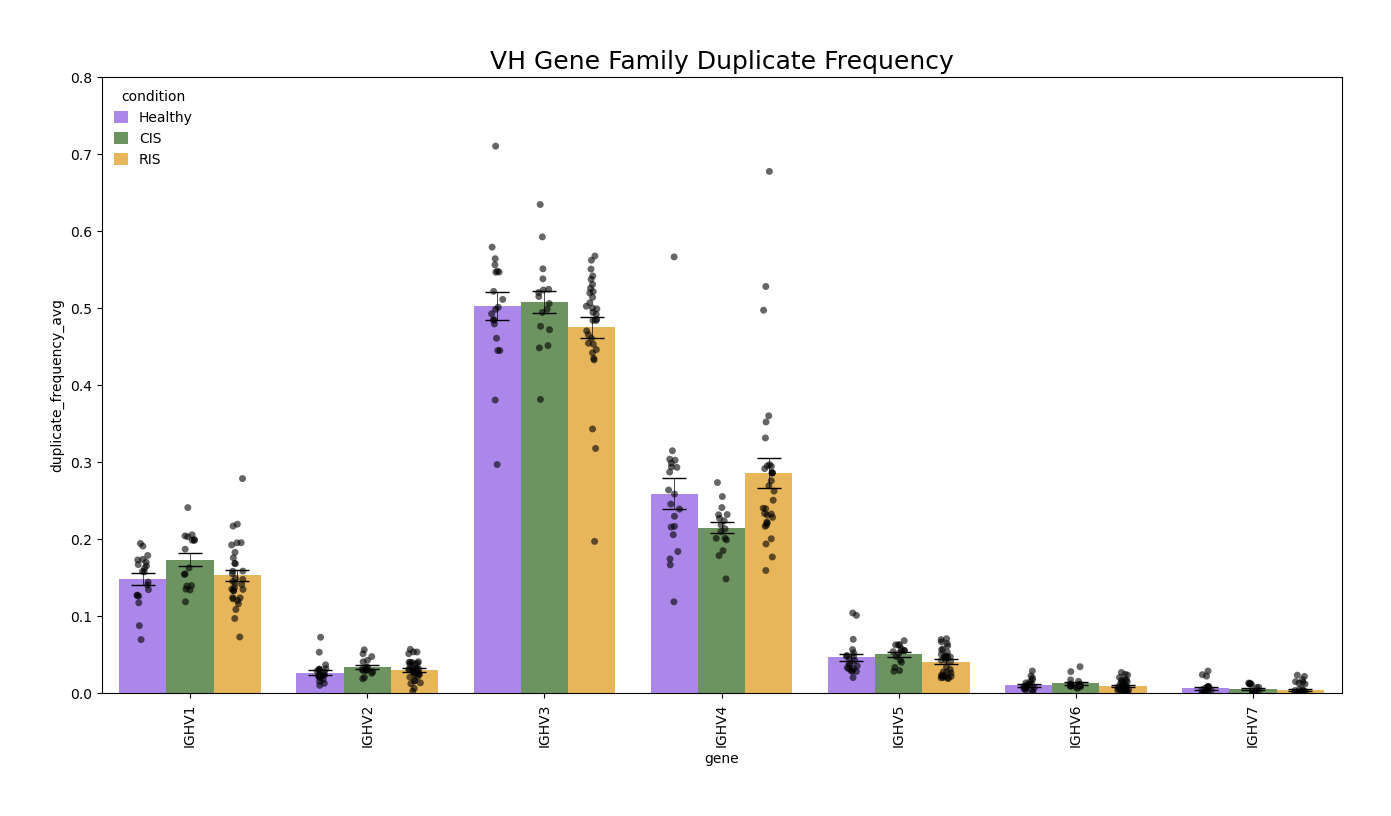

In [71]:
global threshold, ylim, processing_stage, call_type, level
threshold = 0.001 #0.02
ylim = (0,0.8)
processing_stage = 'igblast.makedb.gene.clone'
call_type = 'v_call'
level = 'subgroup'

df = br.load_gene_usage_group_data(
    repcalc_dir=repcalc_dir,
    groups=groups_tuple,
    processing_stage=processing_stage,
    call_type=call_type,
    level=level,
    threshold=threshold
)

datapoints = br.load_gene_usage_group_data(
    repcalc_dir=repcalc_dir,
    groups=groups_tuple,
    processing_stage=processing_stage,
    call_type=call_type,
    level=level,
    threshold=threshold,
    datapoints=True,
    categories=list(df['gene'].unique())
)

fig, ax = gr.plot_duplicate_frequency(
    df=df,
    datapoints=datapoints,
    hue_order=hue_order,
    palette=cond_cmap,
    title={'t':'VH Gene Family Duplicate Frequency', 'fontsize':18},
    ylim=ylim,
    errorbar='se',
    split=True,
    legend=True
)

fig.show()

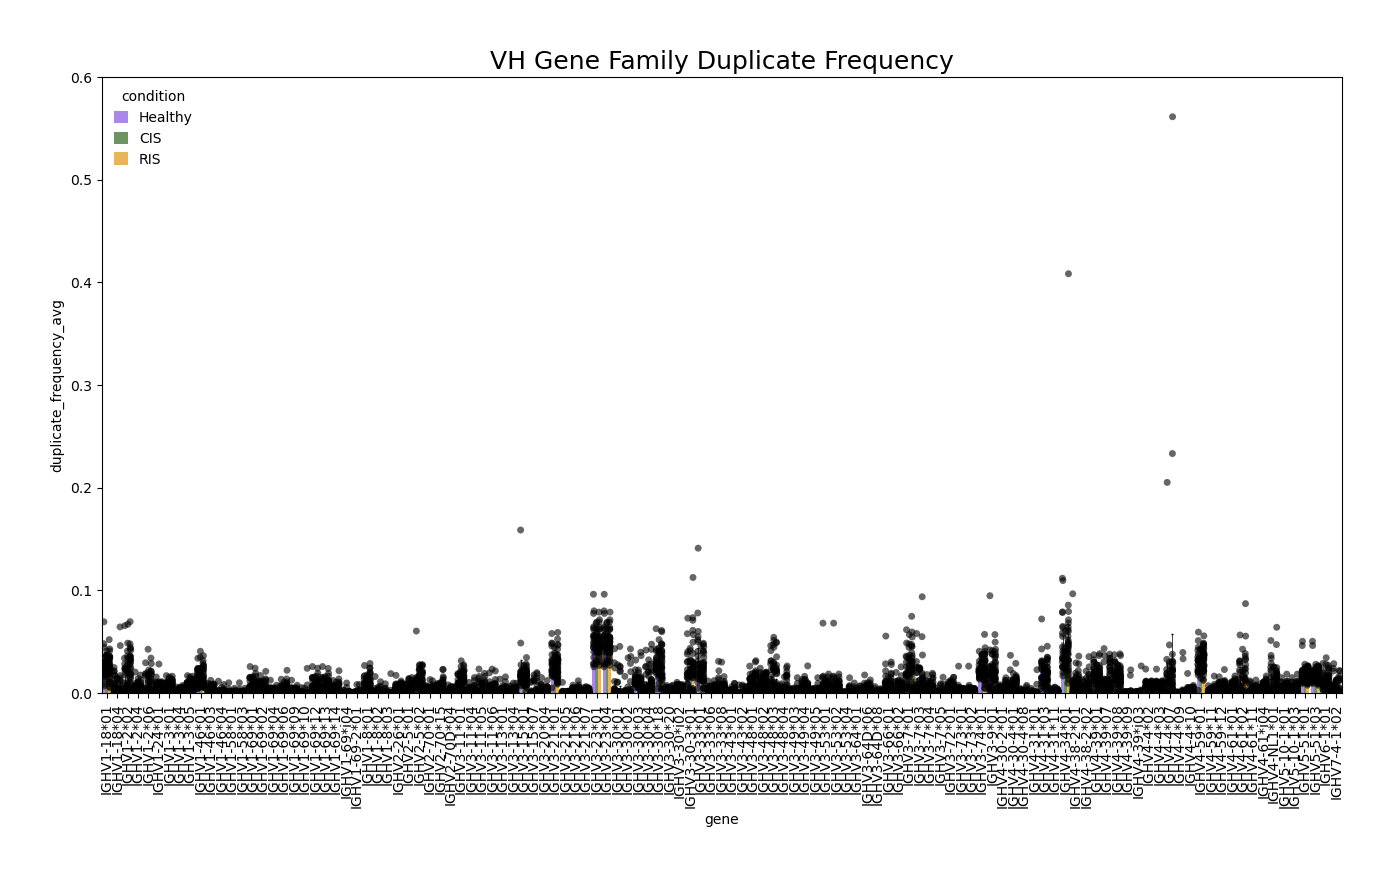

In [72]:
# *** fix gene display??? ***

global threshold, ylim, processing_stage, call_type, level
threshold = 0.001 #0.02
ylim = (0,0.6)
processing_stage = 'igblast.makedb.gene.clone'
call_type = 'v_call'
level = 'allele'

df = br.load_gene_usage_group_data(
    repcalc_dir=repcalc_dir,
    groups=groups_tuple,
    processing_stage=processing_stage,
    call_type=call_type,
    level=level,
    threshold=threshold
)

datapoints = br.load_gene_usage_group_data(
    repcalc_dir=repcalc_dir,
    groups=groups_tuple,
    processing_stage=processing_stage,
    call_type=call_type,
    level=level,
    threshold=threshold,
    datapoints=True,
    categories=list(df['gene'].unique())
)

fig, ax = gr.plot_duplicate_frequency(
    df=df,
    datapoints=datapoints,
    hue_order=hue_order,
    palette=cond_cmap,
    title={'t':'VH Gene Family Duplicate Frequency', 'fontsize':18},
    ylim=ylim,
    errorbar='se',
    split=True,
    legend=True
)

fig.show()

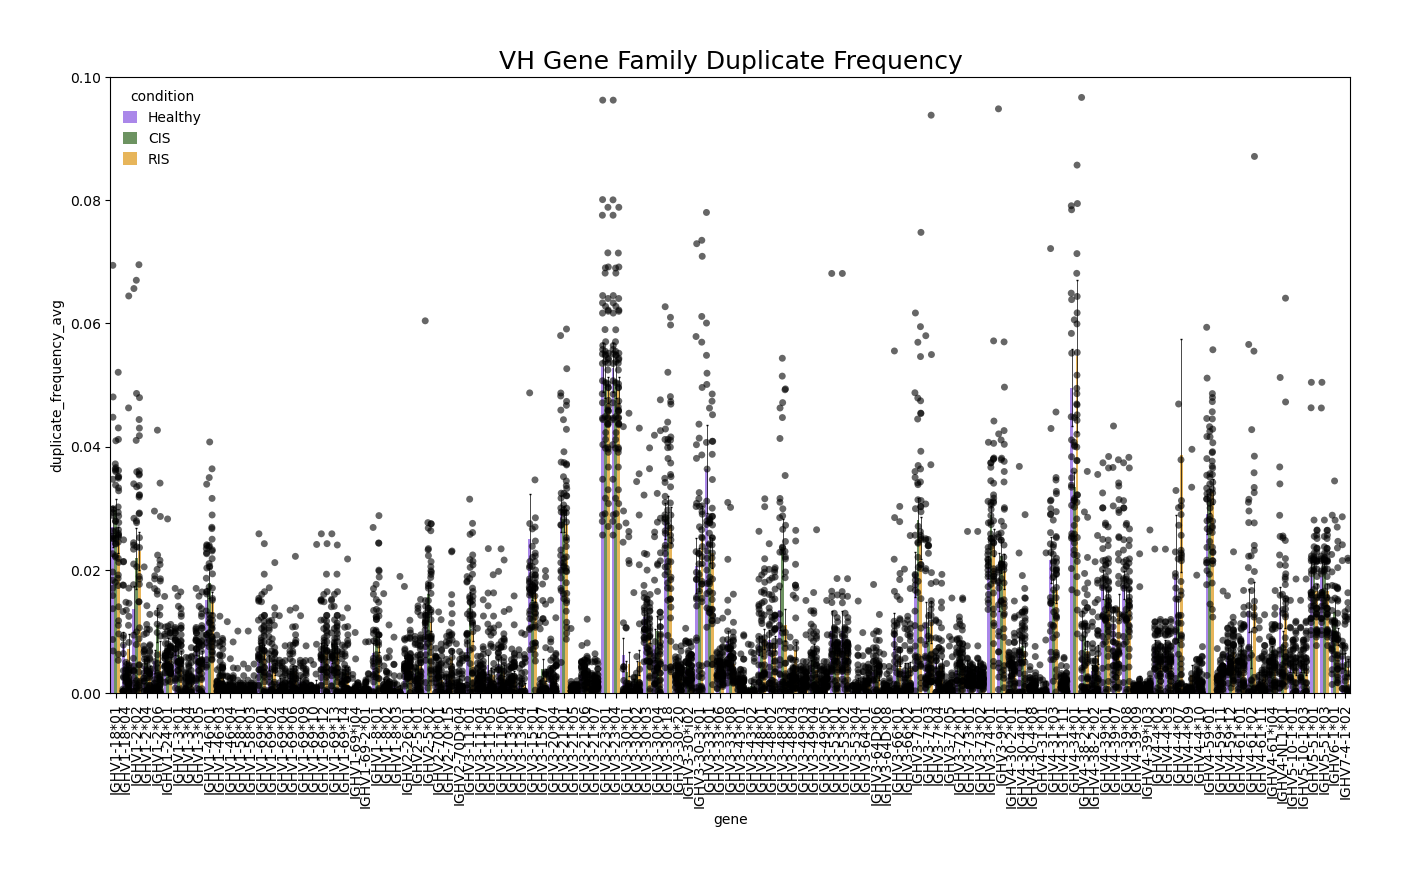

In [73]:
# *** fix gene display??? ***

global threshold, ylim, processing_stage, call_type, level
threshold = 0.001 #0.02
ylim = (0,0.1)
processing_stage = 'igblast.makedb.gene.clone'
call_type = 'v_call'
level = 'allele'

df = br.load_gene_usage_group_data(
    repcalc_dir=repcalc_dir,
    groups=groups_tuple,
    processing_stage=processing_stage,
    call_type=call_type,
    level=level,
    threshold=threshold
)

datapoints = br.load_gene_usage_group_data(
    repcalc_dir=repcalc_dir,
    groups=groups_tuple,
    processing_stage=processing_stage,
    call_type=call_type,
    level=level,
    threshold=threshold,
    datapoints=True,
    categories=list(df['gene'].unique())
)

fig, ax = gr.plot_duplicate_frequency(
    df=df,
    datapoints=datapoints,
    hue_order=hue_order,
    palette=cond_cmap,
    title={'t':'VH Gene Family Duplicate Frequency', 'fontsize':18},
    ylim=ylim,
    errorbar='se',
    split=True,
    legend=True
)

fig.show()

## Heat maps

#### Normalized Difference

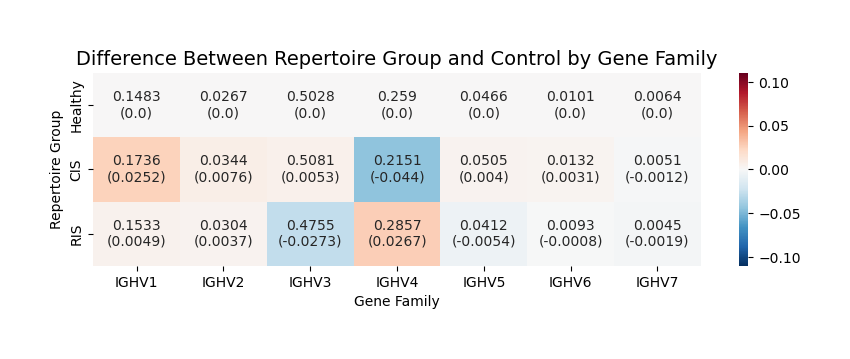

In [27]:
global threshold, ylim, processing_stage, call_type, level
threshold = 0.001 #0.02
ylim = (0,1)
processing_stage = 'igblast.makedb.gene.clone'
call_type = 'v_call'
level = 'subgroup'

df = br.load_gene_usage_group_data(
        repcalc_dir=repcalc_dir,
        groups=groups_tuple,
        processing_stage=processing_stage,
        call_type=call_type,
        level=level,
        threshold=threshold
    )

if groups_of_interest:
    idx = groups_of_interest
else:
    idx = list(df['condition'].unique())

matrix = df.pivot(
    index="condition",
    columns="gene",
    values="duplicate_frequency_avg"
).reindex(idx)

# make sure matrix is numeric
matrix = matrix.astype(float)

# make normalized matrix
norm_mat = norm_cols(matrix, 'difference')

# make annotation matrix
annot_mat = make_annotation_mat(matrix, norm_mat, 4, 4)

# make figure
n_rows, n_cols = matrix.shape
fig, ax = plt.subplots(figsize=(1.4*n_cols, 0.5*n_rows+1))

sns.heatmap(
    norm_mat,
    annot=annot_mat,
    fmt='',
    cmap="RdBu_r",
    vmin=-0.11,
    vmax=0.11,
    ax=ax
)

ax.set_title(
    'Difference Between Repertoire Group and Control by Gene Family',
    fontdict={'fontsize':14}
)
ax.set_ylabel('Repertoire Group')
ax.set_xlabel('Gene Family')

fig.show()

# J

## Bar graph

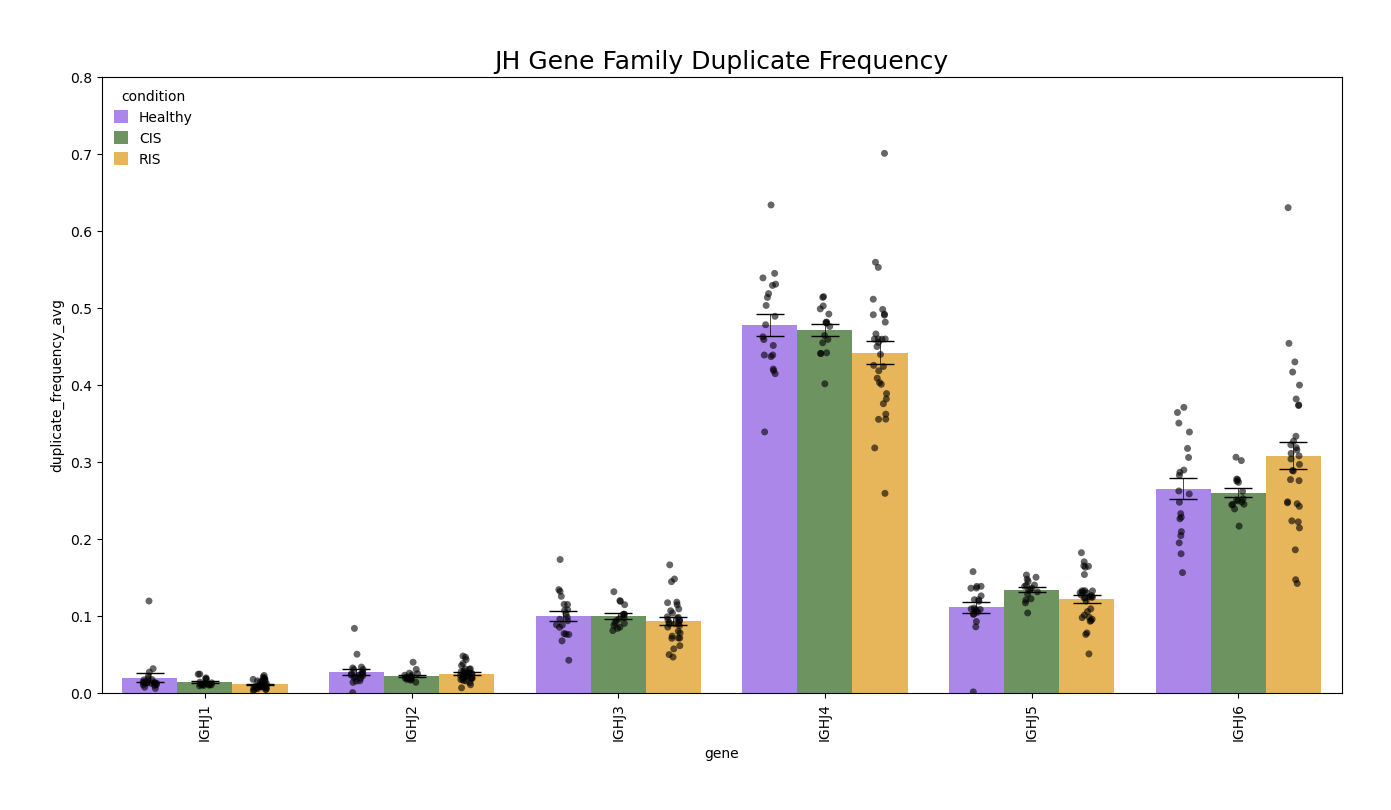

In [74]:
global threshold, ylim, processing_stage, call_type, level
threshold = 0.001 #0.02
ylim = (0,0.8)
processing_stage = 'igblast.makedb.gene.clone'
call_type = 'j_call'
level = 'subgroup'

df = br.load_gene_usage_group_data(
    repcalc_dir=repcalc_dir,
    groups=groups_tuple,
    processing_stage=processing_stage,
    call_type=call_type,
    level=level,
    threshold=threshold
)

datapoints = br.load_gene_usage_group_data(
    repcalc_dir=repcalc_dir,
    groups=groups_tuple,
    processing_stage=processing_stage,
    call_type=call_type,
    level=level,
    threshold=threshold,
    datapoints=True,
    categories=list(df['gene'].unique())
)

fig, ax = gr.plot_duplicate_frequency(
    df=df,
    datapoints=datapoints,
    hue_order=hue_order,
    palette=cond_cmap,
    title={'t':'JH Gene Family Duplicate Frequency', 'fontsize':18},
    ylim=ylim,
    errorbar='se',
    split=True,
    legend=True
)

fig.show()

## Heat maps

#### Normalized Difference

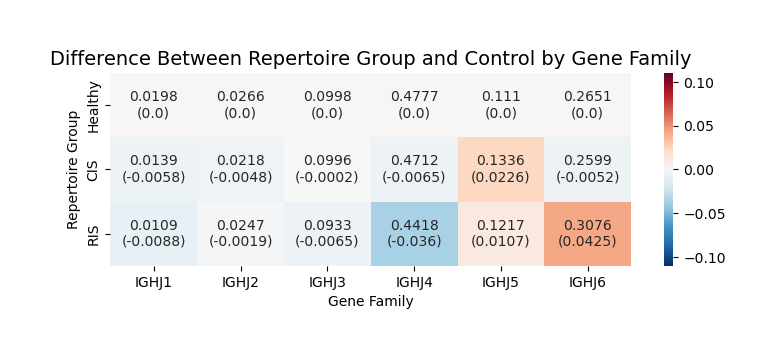

In [26]:
global threshold, ylim, processing_stage, call_type, level
threshold = 0.001 #0.02
ylim = (0,1)
processing_stage = 'igblast.makedb.gene.clone'
call_type = 'j_call'
level = 'subgroup'

df = br.load_gene_usage_group_data(
        repcalc_dir=repcalc_dir,
        groups=groups_tuple,
        processing_stage=processing_stage,
        call_type=call_type,
        level=level,
        threshold=threshold
    )

if groups_of_interest:
    idx = groups_of_interest
else:
    idx = list(df['condition'].unique())

matrix = df.pivot(
    index="condition",
    columns="gene",
    values="duplicate_frequency_avg"
).reindex(idx)

# make sure matrix is numeric
matrix = matrix.astype(float)

# make normalized matrix
norm_mat = norm_cols(matrix, 'difference')

# make annotation matrix
annot_mat = make_annotation_mat(matrix, norm_mat, 4, 4)

# make figure
n_rows, n_cols = matrix.shape
fig, ax = plt.subplots(figsize=(1.4*n_cols, 0.5*n_rows+1))

sns.heatmap(
    norm_mat,
    annot=annot_mat,
    fmt='',
    cmap="RdBu_r",
    vmin=-0.11,
    vmax=0.11,
    ax=ax
)

ax.set_title(
    'Difference Between Repertoire Group and Control by Gene Family',
    fontdict={'fontsize':14}
)
ax.set_ylabel('Repertoire Group')
ax.set_xlabel('Gene Family')

fig.show()

# VJ Combo

## Chord Diagram of VH:JH Gene Pairing 

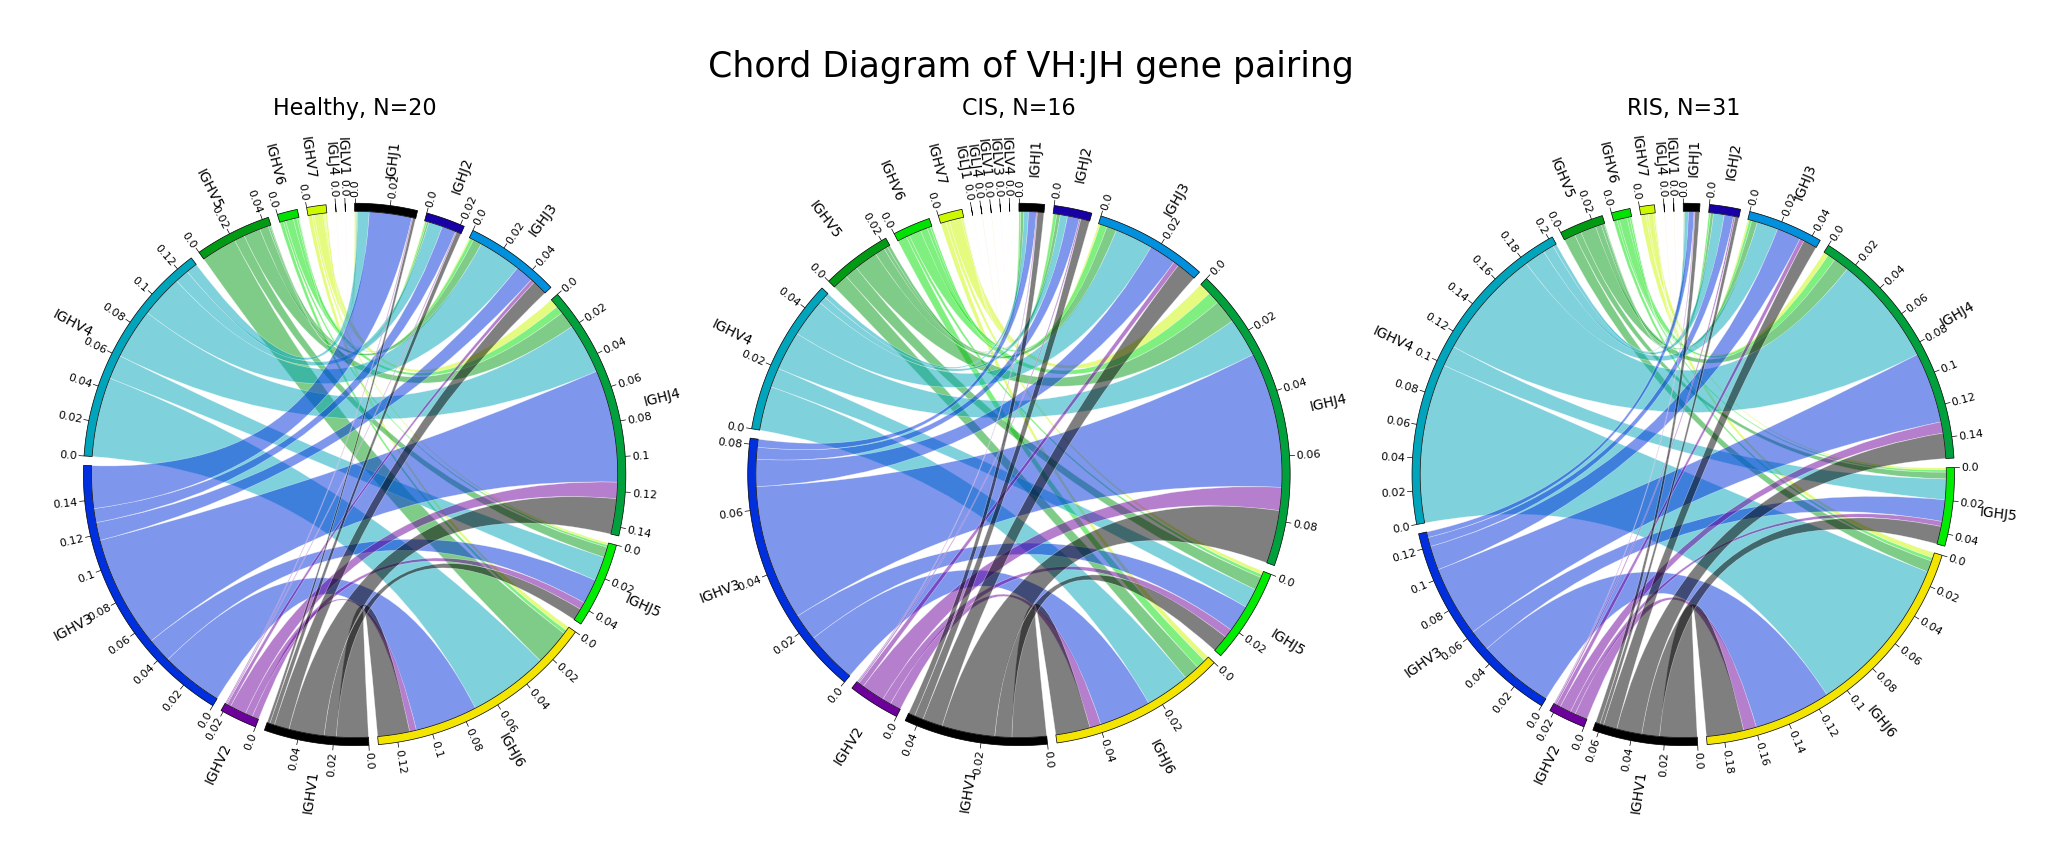

In [ ]:
figsize = (20,8)
nrows = 1
ncols = 3

fig, axes = plt.subplots(
    nrows=nrows, 
    ncols=ncols, 
    figsize=figsize,
    subplot_kw={'projection':'polar'})

max_y_lim=0
for i, group in enumerate(groups_tuple):
    if type(axes) == np.ndarray:
        if i==0:
            axes = axes.flatten()
        ax = axes[i]
    else:
        ax = axes
    gr.plot_vj_chord_diagram(
        df=br.load_and_prepare_data_vj_combo(
            repcalc_dir=repcalc_dir,
            group_id=group[0],
            combo_type='vj_combo',
            processing_stage='.igblast.makedb.gene.clone.group.'
        ),
        freq_col='duplicate_frequency_avg',
        ticks_interval=0.02,
        max_links=None,
        cmap=v_subgroup_cmap | j_subgroup_cmap,
        title={'t':f'{group[1]}, N={len(group[2])}', 'fontsie':16, 'y':1.08},
        ax=ax
    )
    if max_y_lim < ax.get_ylim()[1]:
        max_y_lim = ax.get_ylim()[1]

fontsize=int(max(24, 1.25 * fig.get_size_inches()[0]))

fig.suptitle(**{'t':'Chord Diagram of VH:JH gene pairing', 'y':1.0, 'fontsize':fontsize})
plt.tight_layout()
fig.show()

# CDR3

## Bar graph of CDR3 length

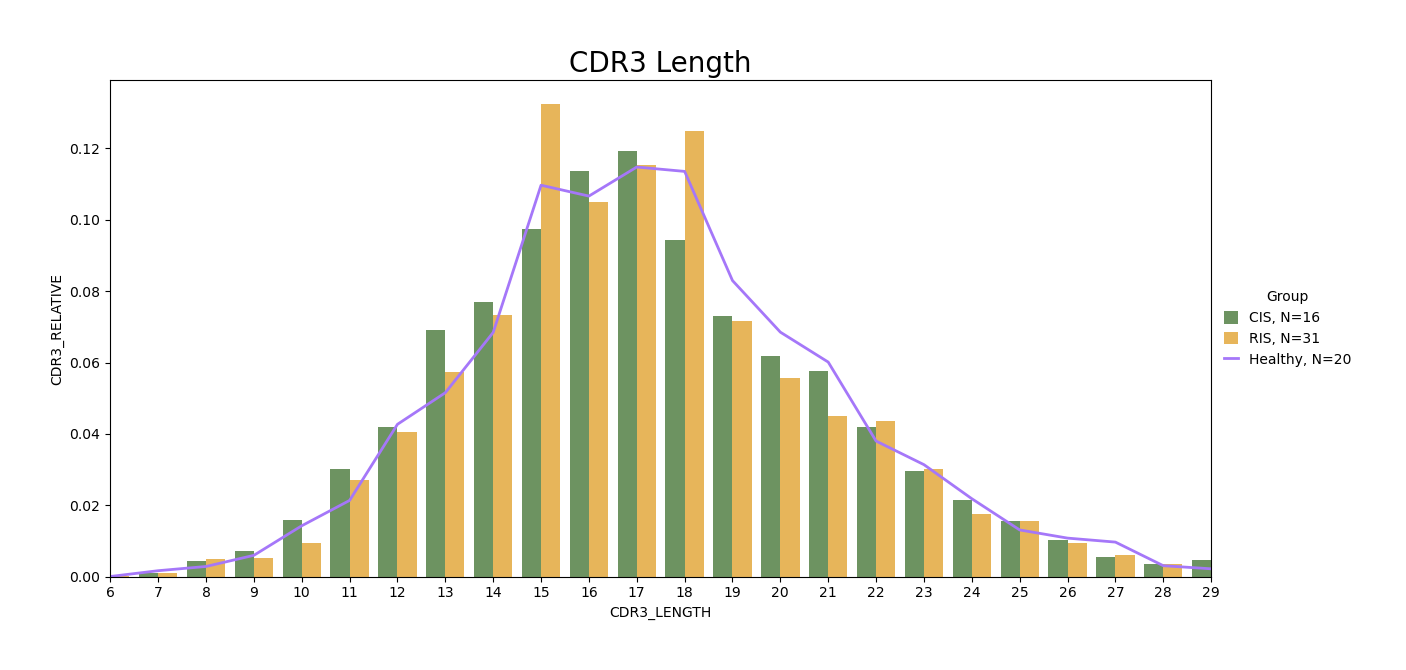

In [39]:
df = br.load_and_prepare_data_junction_aa(
    repcalc_dir=repcalc_dir,
    groups=groups_tuple,
    processing_stage='.igblast.makedb.allele.clone.group.',
    call_type='junction_aa_length'
)
    
fig, ax = gr.plot_junction_aa_length(
    df=df,
    x_col='CDR3_LENGTH',
    y_col='CDR3_RELATIVE',
    controls=control_group_names,
    hue_col='condition',
    palette=cond_cmap,
    legend=True,
    title={'t':'CDR3 Length', 'y':1.0, 'fontsize':20},
    figsize=(12,6)
)

# add N for labels
add_N_to_legend(ax, groups_tuple)

fig.show()

## Headgehog of Overall RF

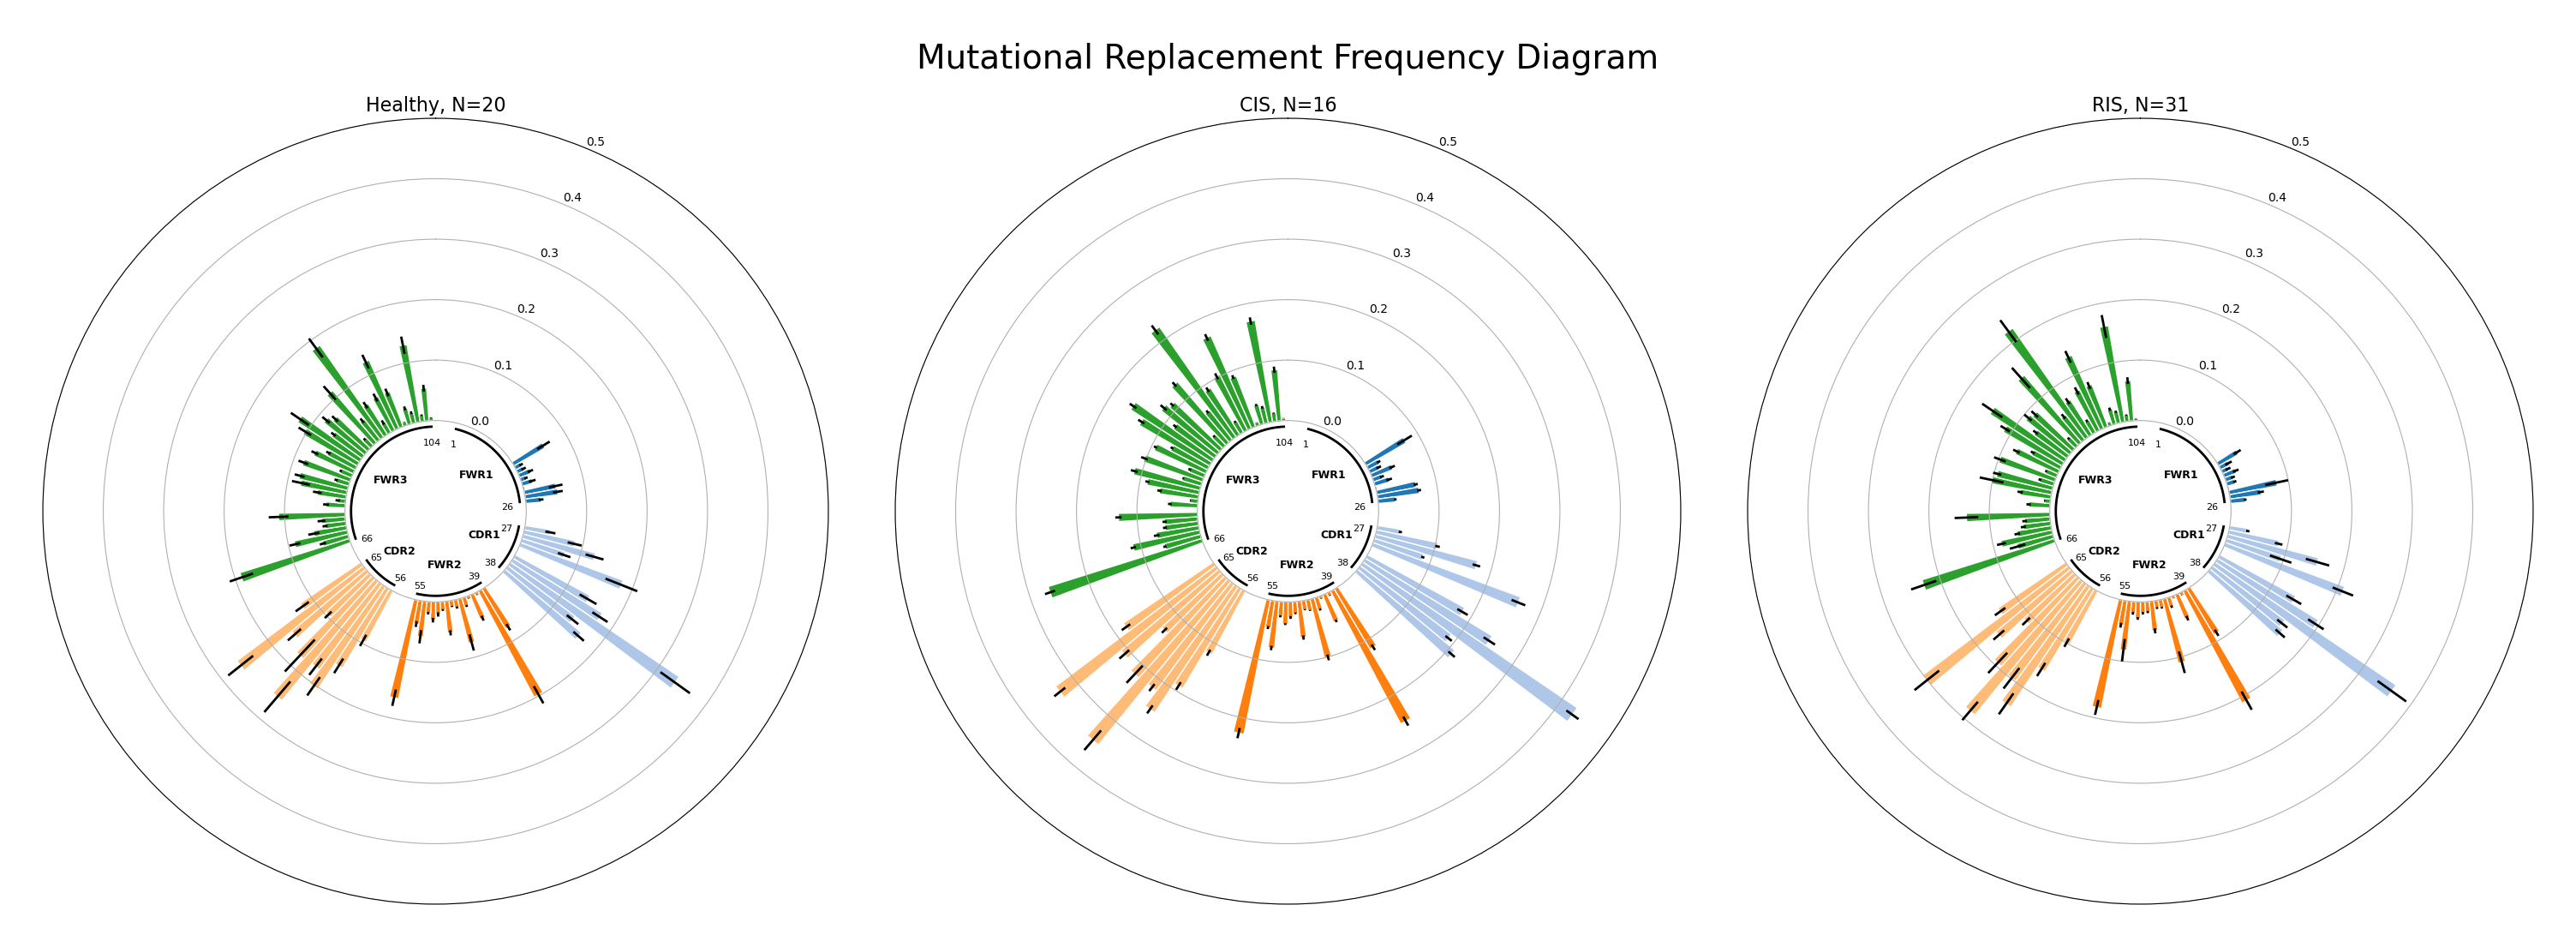

In [17]:
nrows = 1
ncols = 3
figsize = (10,10)

fig, axes = plt.subplots(
    nrows=nrows, 
    ncols=ncols, 
    figsize=((figsize[0]*ncols), (figsize[1]*nrows)),
    subplot_kw={'projection':'polar'})

max_y_lim=0
for i, group in enumerate(groups_tuple):
    if type(axes) == np.ndarray:
        if i==0:
            axes = axes.flatten()
        ax = axes[i]
    else:
        ax = axes
    gr.plot_mutational_hedgehog(
        df=br.load_and_prepare_mutation_data(
            mutation_data_dir=repcalc_dir,
            repertoire_groups=[group],
            trim_codons=16,
            processing_stage='igblast.makedb.gene.clone.mutations'
        ),
        title={'t':f'{group[1]}, N={len(group[2])}', 'fontsize':16},
        ax=ax
    )
    if max_y_lim < ax.get_ylim()[1]:
        max_y_lim = ax.get_ylim()[1]


# fontsize=int(max(24, 1.25 * fig.get_size_inches()[0]))
fig.suptitle(**{'t':'Mutational Replacement Frequency Diagram','y':1.02, 'fontsize':28})

for ax in axes:
    ax.set_ylim(-0.15, max_y_lim)
    ax.yaxis.grid(True)
    ax.yaxis.set_major_locator(MaxNLocator(7))

    ticks = ax.get_yticks()
    ax.set_yticks([t for t in ticks if t >=0])  # remove the last one

plt.tight_layout()
fig.show()

## Clonal Expansion

### Abundance

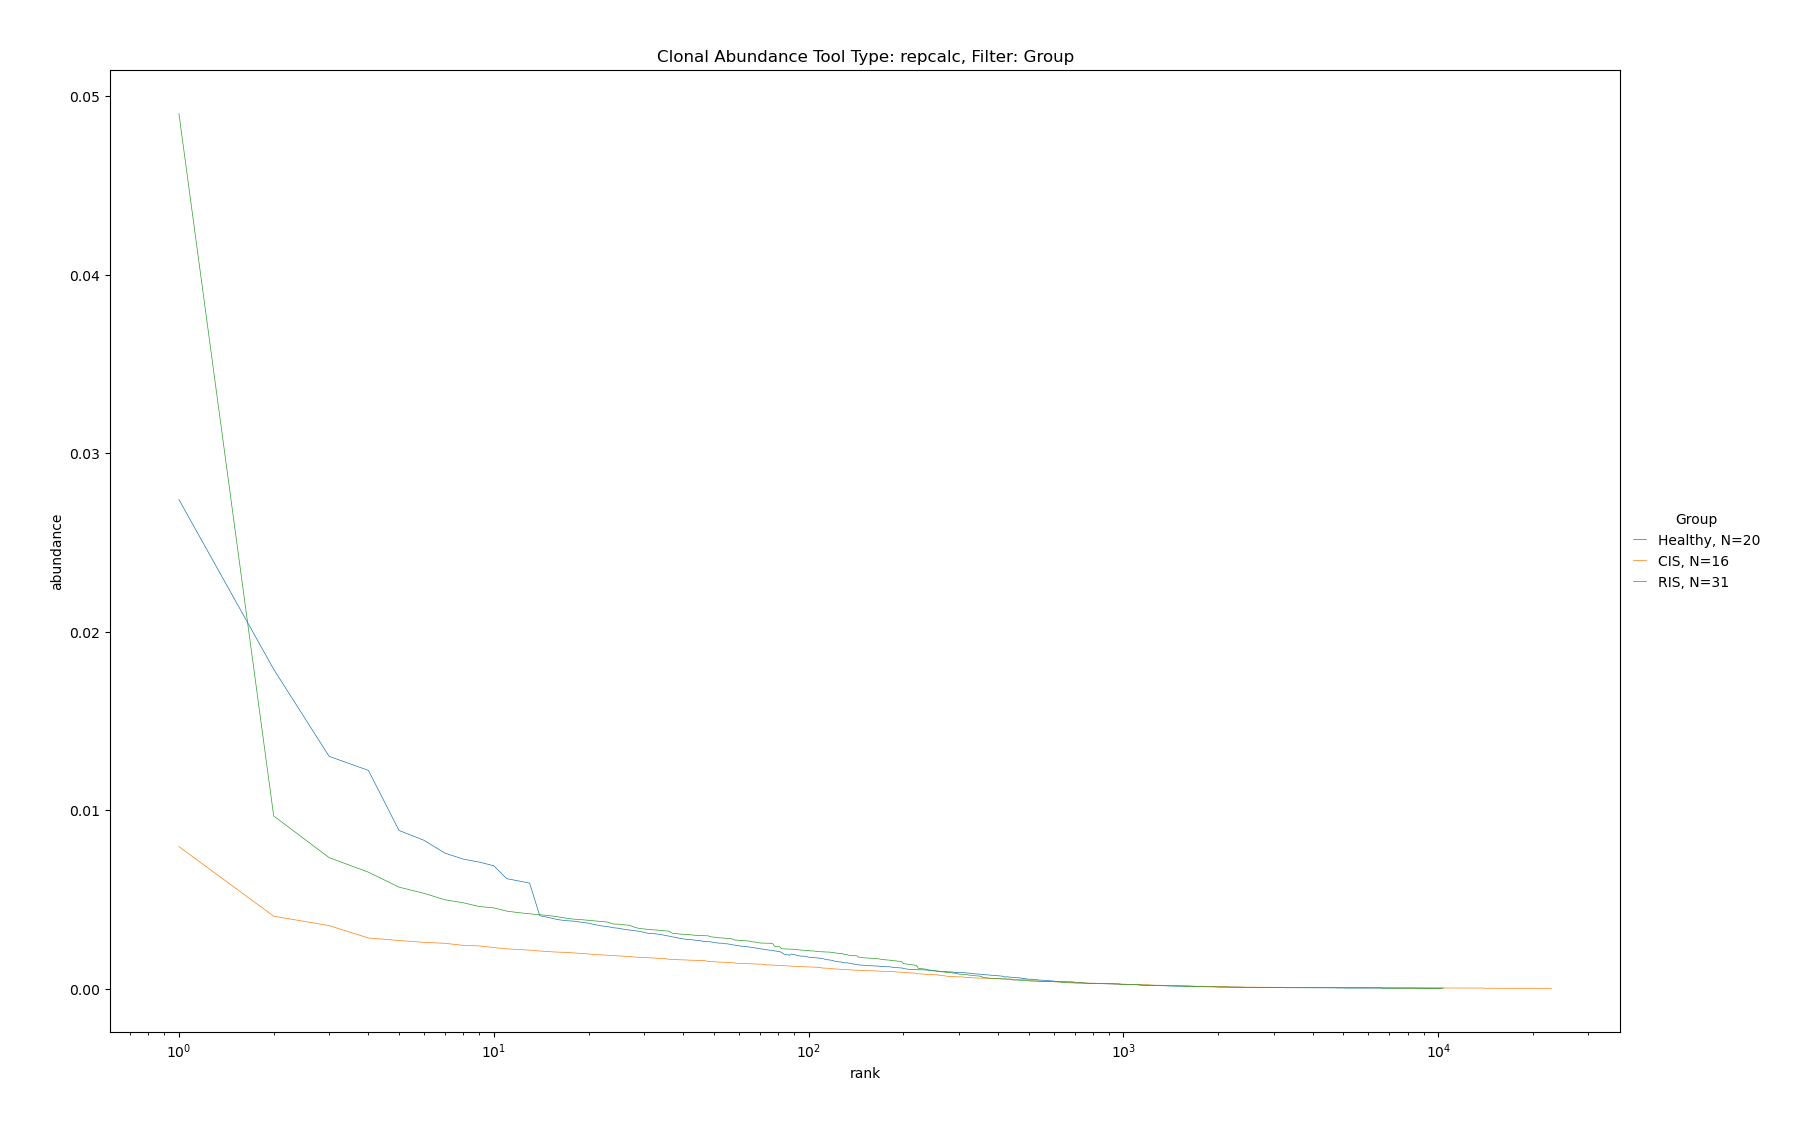

In [50]:
processing_stage = 'igblast.makedb.allele.clone'
clone_tool = 'repcalc' # repcalc, changeo

df = br.load_and_prepare_clonal_abundance_group_data(
    repcalc_dir,
    groups_tuple,
    all_groups=repertoire_groups,
    all_repertoires=repertoires,
    clone_tool=clone_tool,
    processing_stage=processing_stage
)

fig, ax = gr.plot_clonal_abundance(
    df,
    y_col = 'abundance',
    figsize=(16, 12),
    title = f'Clonal Abundance Tool Type: {clone_tool}, Filter: Group',
    legend_title = 'Group Name',
    hue='condition'
)

add_N_to_legend(ax, groups_tuple)

fig.show()

### Cumulative Abundance

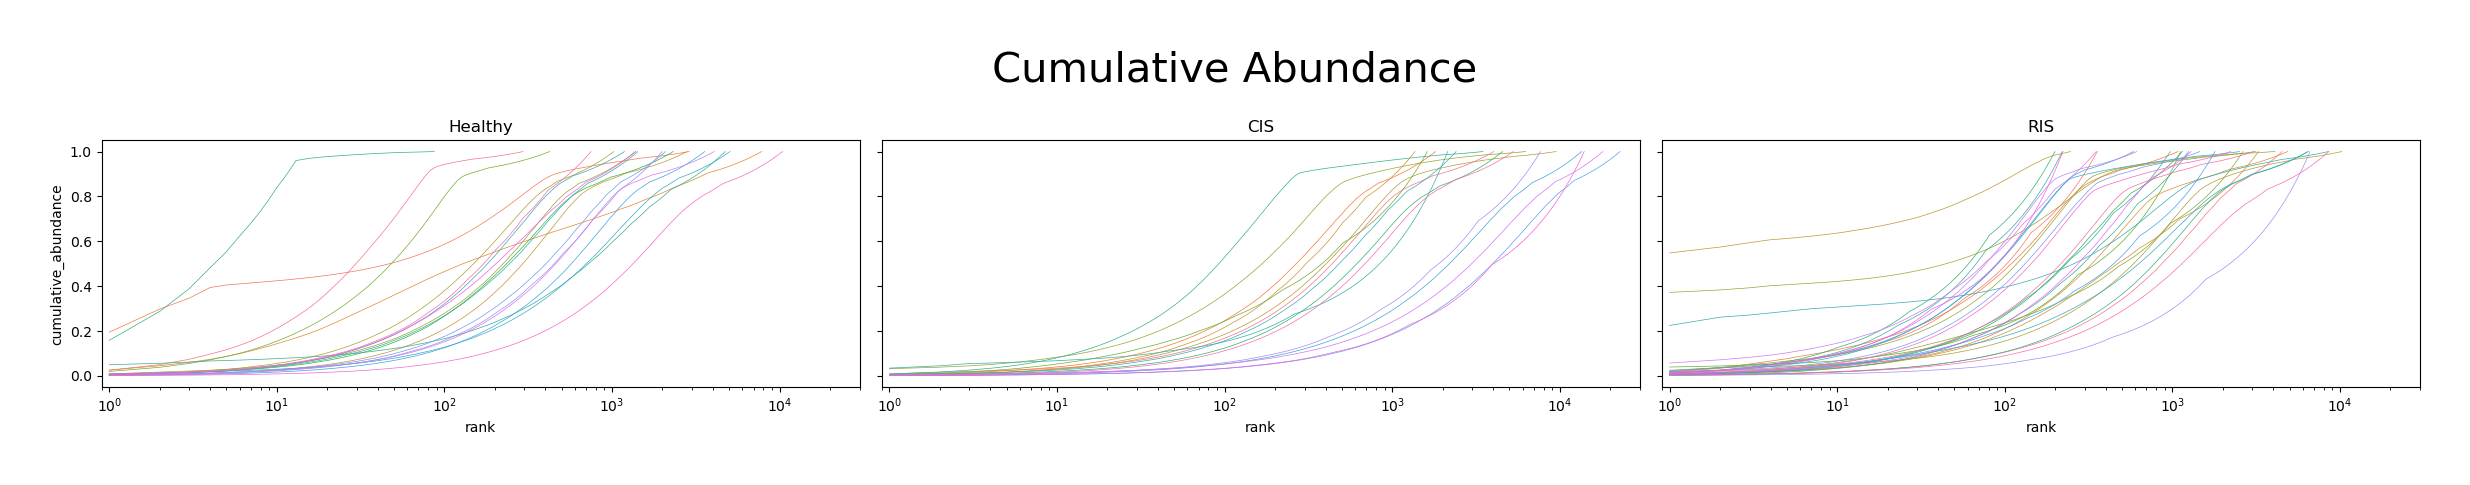

In [51]:
processing_stage = 'igblast.makedb.allele.clone'
clone_tool = 'repcalc' # repcalc, changeo

nrows = 1
ncols = 3

fig, axes = plt.subplots(
    nrows=nrows, 
    ncols=ncols, 
    figsize=(8*ncols, 4*nrows),
    sharex=True,
    sharey=True
)

for i, group in enumerate(groups_tuple):
    if type(axes) == np.ndarray:
        if i==0:
            axes = axes.flatten()
        ax = axes[i]
    else:
        ax = axes
    
    df = br.load_and_prepare_clonal_abundance_group_data(
        repcalc_dir,
        [group],
        all_groups=repertoire_groups,
        all_repertoires=repertoires,
        clone_tool=clone_tool,
        processing_stage=processing_stage
    )

    gr.plot_clonal_abundance(
        df[df['condition']==group[1]],
        y_col = 'cumulative_abundance',
        title = f'{group[1]}',
        legend_title = 'Sample',
        hue='sample_id',
        ax=ax
    )

for ax in axes:
    ax.set_ylim(-0.05,1.05)
    ax.set_xlim(0.9e0, 3e4)
    ax.get_legend().remove()

fontsize=int(max(24, 1.25 * fig.get_size_inches()[0]))
fig.suptitle(**{'t':'Cumulative Abundance','y':1.0, 'fontsize':fontsize})

plt.tight_layout()
fig.show()

### Expansion

In [ ]:
# processing_stage = 'igblast.makedb.allele.clone'
# clone_tool = 'repcalc' # repcalc, changeo

# df = br.load_and_prepare_clonal_abundance_group_data(
#     repcalc_dir,
#     diag_hi_groups_3t7,
#     all_groups=repertoire_groups,
#     all_repertoires=repertoires,
#     clone_tool=clone_tool,
#     processing_stage=processing_stage
# )

# # Assign a distinct color to each category
# unique_labels = df['condition'].unique()
# palette = sns.color_palette('tab10', len(unique_labels))
# color_map = dict(zip(unique_labels, palette))

# plt.figure(figsize=(12, 8))
# for label in unique_labels:
#     subset = df[(df['condition']==label)]
#     subset = subset.sort_values('abundance', ascending=False)
#     subset['group_rank'] = range(1, subset.shape[0]+1)
#     subset = subset[subset['group_rank']<6]

#     plt.scatter(
#         subset['abundance'], subset['seq_freq'],
#         s=(1/(subset['group_rank']**2))*1000,          # scale size if needed
#         color=cond_cmap[label],
#         alpha=0.7,
#         edgecolor='k',
#         label=label
#     )
# plt.xlabel('Abundance')
# plt.ylabel('Sequence Freq')
# plt.legend(title='Condition (Color) / Rank (Size)', bbox_to_anchor=(1.0,0.5))
# plt.title('Test Figure')
# # plt.tight_layout()

In [ ]:
# percentage = False
# similarity_metrics = ['simpson_coefficient', 'jaccard']
# tissue_types = ['cancer_vs_benign', 'all_tissue', 'all_blood', 'tissue_vs_blood']
# tissue_types = ['cancer_vs_benign']
# sharings = ['cdr3_aa_sharing', 'cdr3_nucleotide_sharing', 'cdr3_vj_aa_sharing']
# sharing = sharings[0]


# df['ss_id'] = str(df['clone_id']) + "_" + df['sample_id'] + "_" +  df['condition']
# # old_subjects = ['13N-1', '16M', '17M', '17N', '19M', '19N-1', '46150-1', '46346-1']
# # old_subjects = ['13N-1', '16M', '17M', '17N', '19M', '19N-1']
# #removing old samples from library 25 and 26
# # selected_samples = sample_info_df[~(sample_info_df.subject_id.isin(old_subjects))]
# # selected_samples = selected_samples.sort_values(by = ['subject_id','diagnosis', 'sample_id', 'tissue'])

# repertoire_ids = df.repertoire_id.values
# sample_ids = df.ss_id.values

# path = f"{repcalc_dir}{processing_stage}.{sharing}.tsv"
# df = pd.read_csv(path, sep='\t', index_col=0)
# df = df.loc[repertoire_ids, repertoire_ids]
# df.index = sample_ids
# df.columns = sample_ids

# common_matrix = df.copy()
# N = common_matrix.shape[0]
# pairs = []

# for i in range(N):
#     for j in range(i+1, N):  # upper triangle, no diagonal
#         A_count = common_matrix.iloc[i, i]
#         B_count = common_matrix.iloc[j, j]
#         SampleA_name = common_matrix.index[i]
#         SampleB_name = common_matrix.index[j]
#         common = common_matrix.iloc[i, j]
#         overlap_percent_j = common /((A_count+ B_count)-common) * 100 if min(A_count, B_count) > 0 else 0
#         overlap_percent_s = common /min(A_count, B_count)* 100 if min(A_count, B_count) > 0 else 0
#         overlap_percent_a_in_b = common / A_count * 100 if min(A_count, B_count) > 0 else 0
#         overlap_percent_b_in_a = common / B_count * 100 if min(A_count, B_count) > 0 else 0
#         pairs.append({
#             'SampleA_count': A_count,
#             'SampleB_count': B_count,
#             'Common_count': common,
#             'Overlap_percent_jaccard': overlap_percent_j,
#             'Overlap_percent_simpson': overlap_percent_s,
#             'overlap_percent_a_in_b': overlap_percent_a_in_b,
#             'overlap_percent_b_in_a': overlap_percent_b_in_a,
#             'SampleA_name': SampleA_name,
#             'SampleB_name': SampleB_name
#         })

# df_pairs = pd.DataFrame(pairs)
# df_pairs = df_pairs[df_pairs.Overlap_percent_jaccard > 10]
# print(df_pairs.shape)
# print(df_pairs)
# # Plot
# plt.figure(figsize=(20,16))
# scatter = plt.scatter(
#     df_pairs['SampleA_count'], 
#     df_pairs['SampleB_count'], 
#     s=df_pairs['Common_count'],  
#     c=df_pairs['Overlap_percent_jaccard'], 
#     cmap='viridis', 
#     alpha=0.7, 
#     edgecolors='k'
# )

# plt.colorbar(scatter, label='Overlap % (relative to smaller sample)')
# plt.xlabel('Rearrangement Count Sample A')
# plt.ylabel('Rearrangement Count Sample B')
# plt.title('Scatter Plot of Sample Sizes vs. Overlap')
# plt.grid(True)

# # Add annotations for each point
# for idx, row in df_pairs.iterrows():
#     label = f"{row['SampleA_name']} - {row['SampleB_name']}"
#     plt.annotate(label, (row['SampleA_count'], row['SampleB_count']),
#                  textcoords="offset points", xytext=(5,-5), ha='right', fontsize=8)

# plt.show()

### Diversity Curve

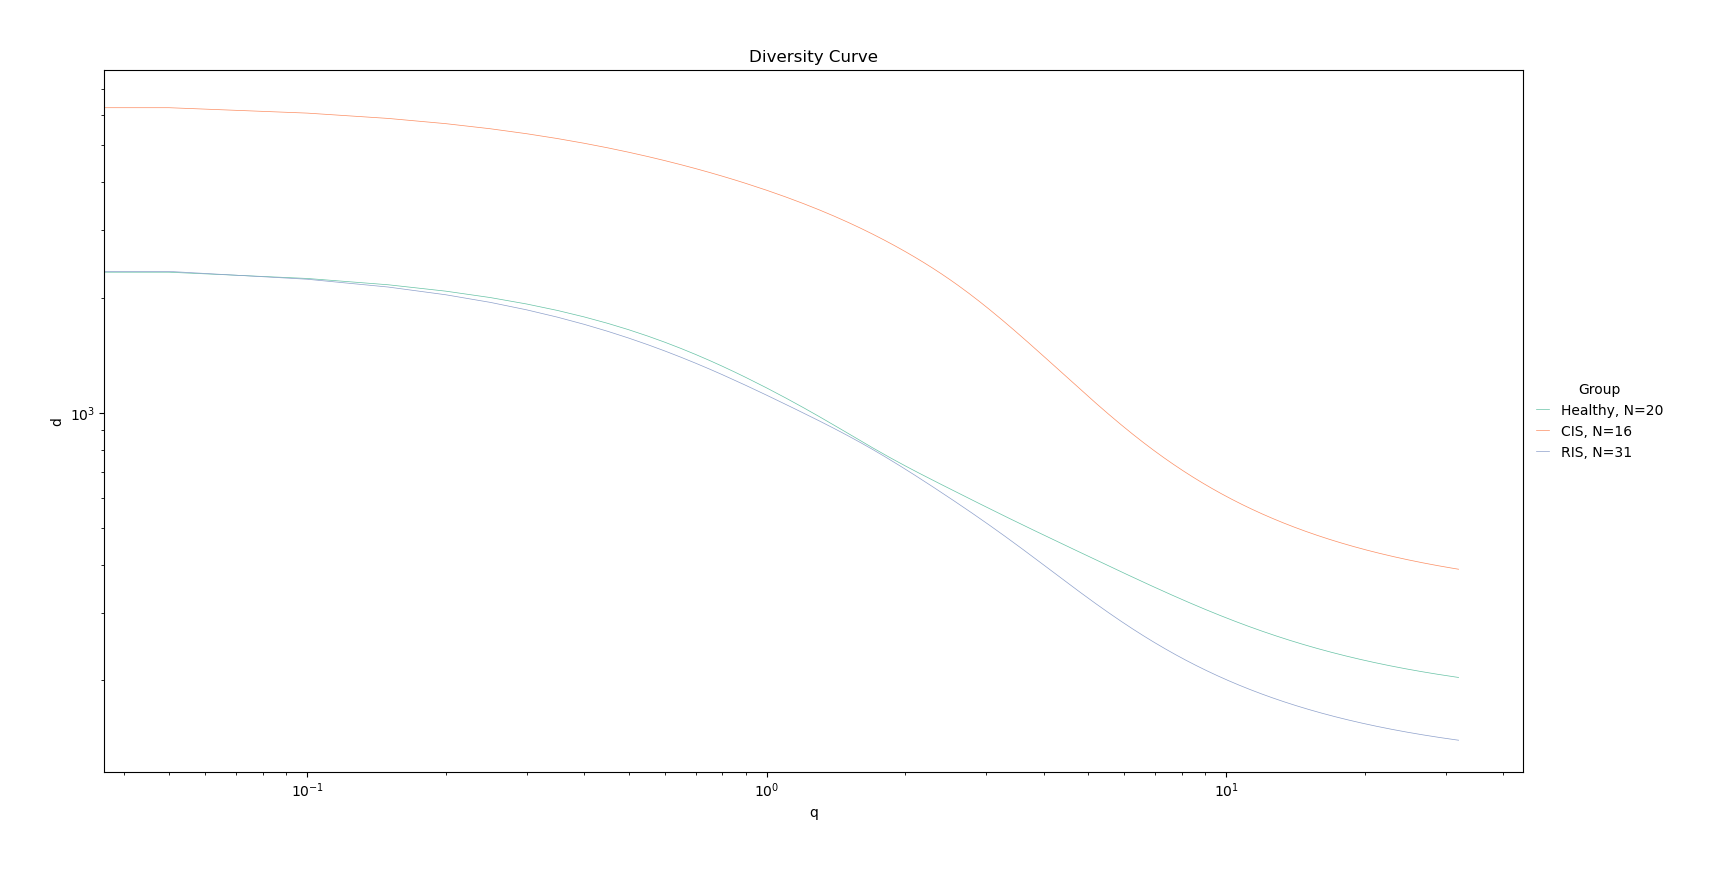

In [52]:
dfs = []
for i, (group_id, group_name, *_) in enumerate(groups_tuple):
        
    df = br.load_diversity_group_data(
        data_dir=repcalc_dir,
        repertoire_group=repertoire_groups[group_id],
        processing_stage='igblast.makedb.gene.clone'
    )
    dfs.append(df)
df = pd.concat(dfs)

fig, ax = gr.plot_diversity_curve(
    df=df,
    title='Diversity Curve',
    legend=True
)

add_N_to_legend(ax, groups_tuple)

fig.show()

### Normalized Shannon Entropy

/tmp/ipykernel_1678556/1568382424.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels)


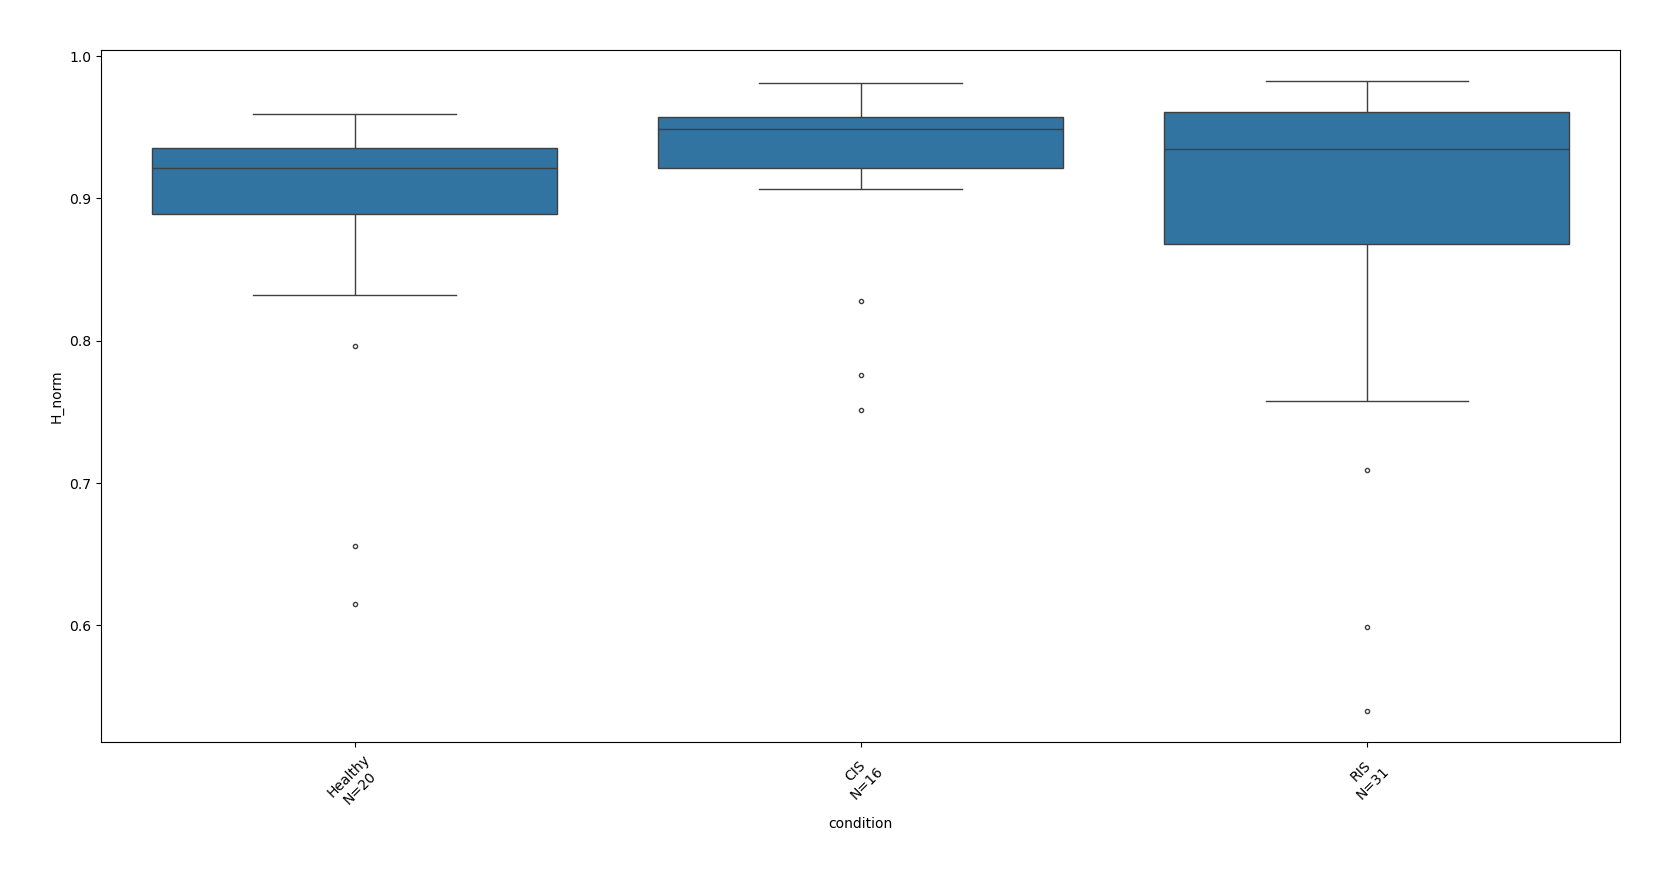

In [53]:
df = br.load_diversity_multiple_group_data(
    data_dir=repcalc_dir,
    repertoire_groups=groups_tuple,
    processing_stage='igblast.makedb.gene.clone',
    all_groups=repertoire_groups
)

fig, ax = gr.plot_diversity_boxplot(
    df=df,
    hue='condition',
    legend=False
)

add_N_to_xaxis(ax, groups_tuple)

fig.show()

## RF and R:S Ratio in CDR and FR

### Dataframe setup

In [54]:
file_path = f"{repcalc_dir}igblast.makedb.gene.clone.mutations.repertoire_group.frequency.mutational_report.csv"
# file_path = f"{repcalc_dir}igblast.makedb.gene.clone.mutations.repertoire.frequency.mutational_report.csv"
group_muts = pd.read_csv(file_path, index_col='repertoire_group_id')
group_muts = group_muts[group_muts.index.isin([gt[0] for gt in groups_tuple])]

ratio_cols = [ 'mu_ratio_fwr_avg', 'mu_ratio_fwr_std', 'mu_ratio_fwr_N', 'mu_ratio_fwr_r_avg', 'mu_ratio_fwr_r_std', 'mu_ratio_fwr_r_N', 'mu_ratio_fwr_s_avg', 'mu_ratio_fwr_s_std', 'mu_ratio_fwr_s_N', 
               'mu_ratio_cdr_avg', 'mu_ratio_cdr_std', 'mu_ratio_cdr_N', 'mu_ratio_cdr_r_avg', 'mu_ratio_cdr_r_std', 'mu_ratio_cdr_r_N', 'mu_ratio_cdr_s_avg', 'mu_ratio_cdr_s_std', 'mu_ratio_cdr_s_N', 
               'mu_rsratio_cdr_avg', 'mu_rsratio_cdr_std', 'mu_rsratio_cdr_N', 'mu_rsratio_fwr_avg', 'mu_rsratio_fwr_std', 'mu_rsratio_fwr_N', 
               'mu_ratio_fwr_aa_avg', 'mu_ratio_fwr_aa_std', 'mu_ratio_fwr_aa_N', 'mu_ratio_fwr_r_aa_avg', 'mu_ratio_fwr_r_aa_std', 'mu_ratio_fwr_r_aa_N', 'mu_ratio_fwr_s_aa_avg', 'mu_ratio_fwr_s_aa_std', 'mu_ratio_fwr_s_aa_N',
               'mu_ratio_cdr_aa_avg', 'mu_ratio_cdr_aa_std', 'mu_ratio_cdr_aa_N', 'mu_ratio_cdr_r_aa_avg', 'mu_ratio_cdr_r_aa_std', 'mu_ratio_cdr_r_aa_N', 'mu_ratio_cdr_s_aa_avg', 'mu_ratio_cdr_s_aa_std', 'mu_ratio_cdr_s_aa_N',
               'mu_rsratio_cdr_aa_avg', 'mu_rsratio_cdr_aa_std', 'mu_rsratio_cdr_aa_N', 'mu_rsratio_fwr_aa_avg', 'mu_rsratio_fwr_aa_std', 'mu_rsratio_fwr_aa_N',]

freq_cols = [ 'mu_freq_avg', 'mu_freq_std', 'mu_freq_N', 'mu_freq_r_avg', 'mu_freq_r_std', 'mu_freq_r_N', 'mu_freq_s_avg', 'mu_freq_s_std', 'mu_freq_s_N',
              'mu_freq_aa_avg', 'mu_freq_aa_std', 'mu_freq_aa_N', 'mu_freq_r_aa_avg', 'mu_freq_r_aa_std', 'mu_freq_r_aa_N', 'mu_freq_s_aa_avg', 'mu_freq_s_aa_std', 'mu_freq_s_aa_N', 
              'mu_freq_fwr_avg', 'mu_freq_fwr_std', 'mu_freq_fwr_N', 'mu_freq_fwr_r_avg', 'mu_freq_fwr_r_std', 'mu_freq_fwr_r_N', 'mu_freq_fwr_s_avg', 'mu_freq_fwr_s_std', 'mu_freq_fwr_s_N',
              'mu_freq_cdr_avg', 'mu_freq_cdr_std', 'mu_freq_cdr_N', 'mu_freq_cdr_r_avg', 'mu_freq_cdr_r_std', 'mu_freq_cdr_r_N', 'mu_freq_cdr_s_avg', 'mu_freq_cdr_s_std', 'mu_freq_cdr_s_N',
              'mu_freq_fwr1_avg', 'mu_freq_fwr1_std', 'mu_freq_fwr1_N', 'mu_freq_fwr1_r_avg', 'mu_freq_fwr1_r_std', 'mu_freq_fwr1_r_N', 'mu_freq_fwr1_s_avg', 'mu_freq_fwr1_s_std', 'mu_freq_fwr1_s_N', 
              'mu_freq_cdr1_avg', 'mu_freq_cdr1_std', 'mu_freq_cdr1_N', 'mu_freq_cdr1_r_avg', 'mu_freq_cdr1_r_std', 'mu_freq_cdr1_r_N', 'mu_freq_cdr1_s_avg', 'mu_freq_cdr1_s_std', 'mu_freq_cdr1_s_N', 
              'mu_freq_fwr2_avg', 'mu_freq_fwr2_std', 'mu_freq_fwr2_N', 'mu_freq_fwr2_r_avg', 'mu_freq_fwr2_r_std', 'mu_freq_fwr2_r_N', 'mu_freq_fwr2_s_avg', 'mu_freq_fwr2_s_std', 'mu_freq_fwr2_s_N',
              'mu_freq_cdr2_avg', 'mu_freq_cdr2_std', 'mu_freq_cdr2_N', 'mu_freq_cdr2_r_avg', 'mu_freq_cdr2_r_std', 'mu_freq_cdr2_r_N', 'mu_freq_cdr2_s_avg', 'mu_freq_cdr2_s_std', 'mu_freq_cdr2_s_N', 
              'mu_freq_fwr3_avg', 'mu_freq_fwr3_std', 'mu_freq_fwr3_N', 'mu_freq_fwr3_r_avg', 'mu_freq_fwr3_r_std', 'mu_freq_fwr3_r_N', 'mu_freq_fwr3_s_avg', 'mu_freq_fwr3_s_std', 'mu_freq_fwr3_s_N', 
              'mu_freq_fwr_aa_avg', 'mu_freq_fwr_aa_std', 'mu_freq_fwr_aa_N', 'mu_freq_fwr_r_aa_avg', 'mu_freq_fwr_r_aa_std', 'mu_freq_fwr_r_aa_N', 'mu_freq_fwr_s_aa_avg', 'mu_freq_fwr_s_aa_std',  'mu_freq_fwr_s_aa_N', 
              'mu_freq_cdr_aa_avg', 'mu_freq_cdr_aa_std', 'mu_freq_cdr_aa_N', 'mu_freq_cdr_r_aa_avg', 'mu_freq_cdr_r_aa_std', 'mu_freq_cdr_r_aa_N', 'mu_freq_cdr_s_aa_avg', 'mu_freq_cdr_s_aa_std', 'mu_freq_cdr_s_aa_N', 
              'mu_freq_fwr1_aa_avg', 'mu_freq_fwr1_aa_std', 'mu_freq_fwr1_aa_N', 'mu_freq_fwr1_r_aa_avg', 'mu_freq_fwr1_r_aa_std', 'mu_freq_fwr1_r_aa_N', 'mu_freq_fwr1_s_aa_avg', 'mu_freq_fwr1_s_aa_std', 'mu_freq_fwr1_s_aa_N',
              'mu_freq_cdr1_aa_avg', 'mu_freq_cdr1_aa_std', 'mu_freq_cdr1_aa_N', 'mu_freq_cdr1_r_aa_avg', 'mu_freq_cdr1_r_aa_std', 'mu_freq_cdr1_r_aa_N', 'mu_freq_cdr1_s_aa_avg', 'mu_freq_cdr1_s_aa_std', 'mu_freq_cdr1_s_aa_N',
              'mu_freq_fwr2_aa_avg', 'mu_freq_fwr2_aa_std', 'mu_freq_fwr2_aa_N', 'mu_freq_fwr2_r_aa_avg', 'mu_freq_fwr2_r_aa_std', 'mu_freq_fwr2_r_aa_N', 'mu_freq_fwr2_s_aa_avg', 'mu_freq_fwr2_s_aa_std', 'mu_freq_fwr2_s_aa_N', 
              'mu_freq_cdr2_aa_avg', 'mu_freq_cdr2_aa_std', 'mu_freq_cdr2_aa_N', 'mu_freq_cdr2_r_aa_avg', 'mu_freq_cdr2_r_aa_std', 'mu_freq_cdr2_r_aa_N', 'mu_freq_cdr2_s_aa_avg', 'mu_freq_cdr2_s_aa_std', 'mu_freq_cdr2_s_aa_N',
              'mu_freq_fwr3_aa_avg', 'mu_freq_fwr3_aa_std', 'mu_freq_fwr3_aa_N', 'mu_freq_fwr3_r_aa_avg', 'mu_freq_fwr3_r_aa_std', 'mu_freq_fwr3_r_aa_N', 'mu_freq_fwr3_s_aa_avg', 'mu_freq_fwr3_s_aa_std', 'mu_freq_fwr3_s_aa_N'
]

ratio_df = group_muts.loc[:,ratio_cols]
ratio_df['rearrangement'] = ratio_df.index.to_series().str.extract(r'-(\d+)$')[0].fillna('All').astype(str)
# ratio_df['parent_group'] = [repertoire_groups[ratio_df.index[i]].get('repertoire_group_name') if i < 5 else ' '.join(repertoire_groups[ratio_df.index[i]].get('repertoire_group_name').split(' ')[0:-1]) for i in range(ratio_df.shape[0])]
ratio_df = ratio_df.loc[:,ratio_df.columns[-2:].to_list()+ratio_df.columns[:-2].to_list()]
ratio_df = ratio_df.reset_index()
ratio_df['repertoire_group_name'] = [repertoire_groups[rgid].get('repertoire_group_name') for rgid in ratio_df.loc[:,'repertoire_group_id']]
ratio_df = ratio_df.loc[:,ratio_df.columns[0:3].to_list()+[ratio_df.columns[-1]]+ratio_df.columns[3:-1].to_list()]
ratio_df['repertoire_group_name'] = pd.Categorical(ratio_df['repertoire_group_name'], categories=hue_order, ordered=True) # to put into hue_order
ratio_df = ratio_df.sort_values('repertoire_group_name')

freq_df = group_muts.loc[:,freq_cols]
freq_df['rearrangement'] = freq_df.index.to_series().str.extract(r'-(\d+)$')[0].fillna('All').astype(str)
# freq_df['parent_group'] = [repertoire_groups[freq_df.index[i]].get('repertoire_group_name') if i < 5 else ' '.join(repertoire_groups[freq_df.index[i]].get('repertoire_group_name').split(' ')[0:-1]) for i in range(freq_df.shape[0])]
freq_df = freq_df.loc[:,freq_df.columns[-2:].to_list()+freq_df.columns[:-2].to_list()]
freq_df = freq_df.reset_index()
freq_df['repertoire_group_name'] = [repertoire_groups[rgid].get('repertoire_group_name') for rgid in freq_df.loc[:,'repertoire_group_id']]
freq_df = freq_df.loc[:,freq_df.columns[0:3].to_list()+[freq_df.columns[-1]]+freq_df.columns[3:-1].to_list()]
freq_df['repertoire_group_name'] = pd.Categorical(freq_df['repertoire_group_name'], categories=hue_order, ordered=True) # to put into hue_order
freq_df = freq_df.sort_values('repertoire_group_name')

groups_tuple_repnum_map = {e[1]:len(e[2]) for e in groups_tuple}

### Heatmaps

#### Mutation Frequency FWR

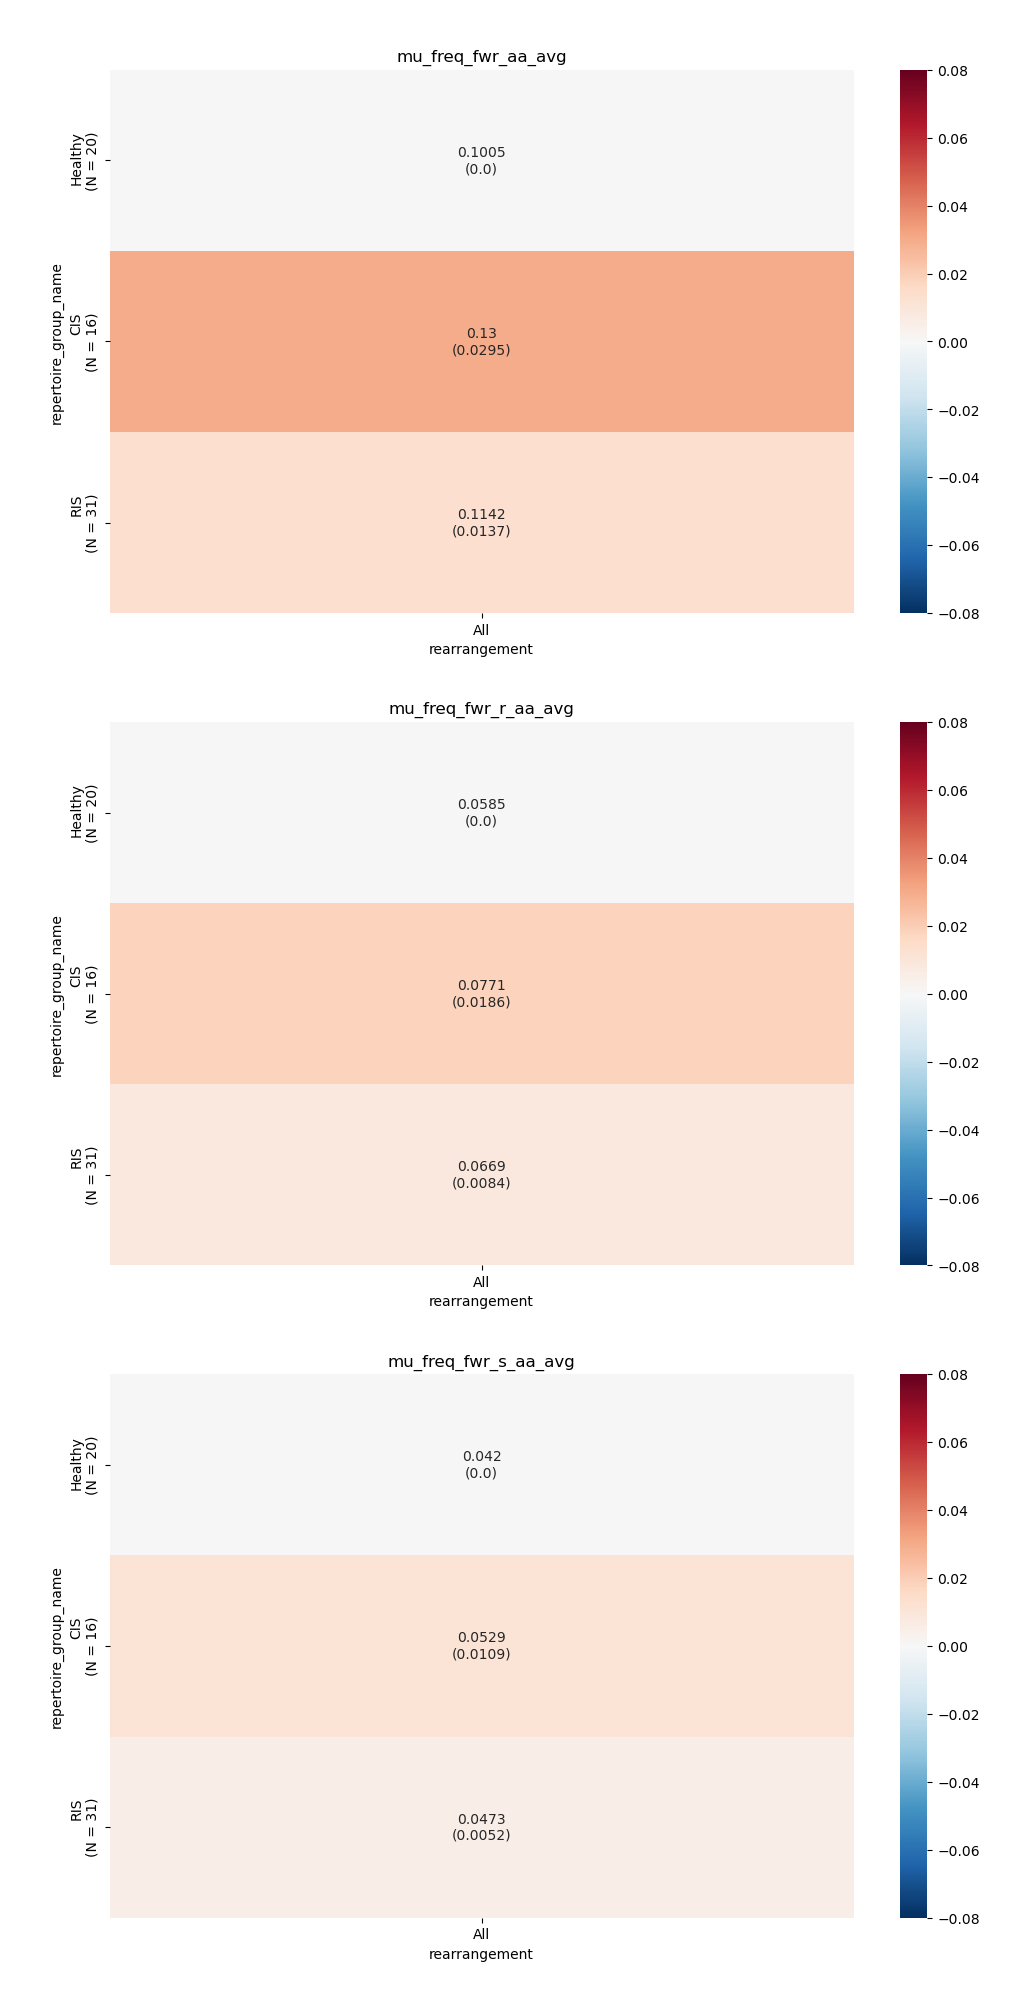

In [55]:
if groups_of_interest:
    idx = groups_of_interest
else:
    idx = list(freq_df['repertoire_group_name'].unique())

value_cols = ['mu_freq_fwr_aa_avg', 'mu_freq_fwr_r_aa_avg', 'mu_freq_fwr_s_aa_avg']
# sns.heatmap(subset)

fig, axes = plt.subplots(3, 1, figsize=(12,24))

for i, value in enumerate(value_cols):
    matrix = freq_df.pivot(
        index="repertoire_group_name",
        columns="rearrangement",
        values=value
    ).reindex(idx)

    # keep only one control group
    # one_control_mat = matrix.drop(matrix.index[0], axis=0)
    one_control_mat = matrix

    # make normalized matrix
    norm_mat = norm_cols(one_control_mat, 'difference')

    # make annotation matrix
    annot_mat = make_annotation_mat(one_control_mat, norm_mat, 4, 4)

    sns.heatmap(
        norm_mat,
        annot=annot_mat,
        fmt='',
        cmap="RdBu_r",
        vmin=-0.08,
        vmax=0.08,
        ax=axes[i]
    )

    yticklabels = [f'{e.get_text()}\n(N = {groups_tuple_repnum_map[e.get_text()]})' for e in  axes[i].get_yticklabels()]
    axes[i].set_yticklabels(yticklabels)
    axes[i].set_title(value)

fig.show()
# ax.set_title('(A)', x=-0.4, fontsize=14, weight='bold')
# ax.set_ylabel('Repertoire Group')
# ax.set_xlabel('Gene Family')

#### Mutation Frequency CDR

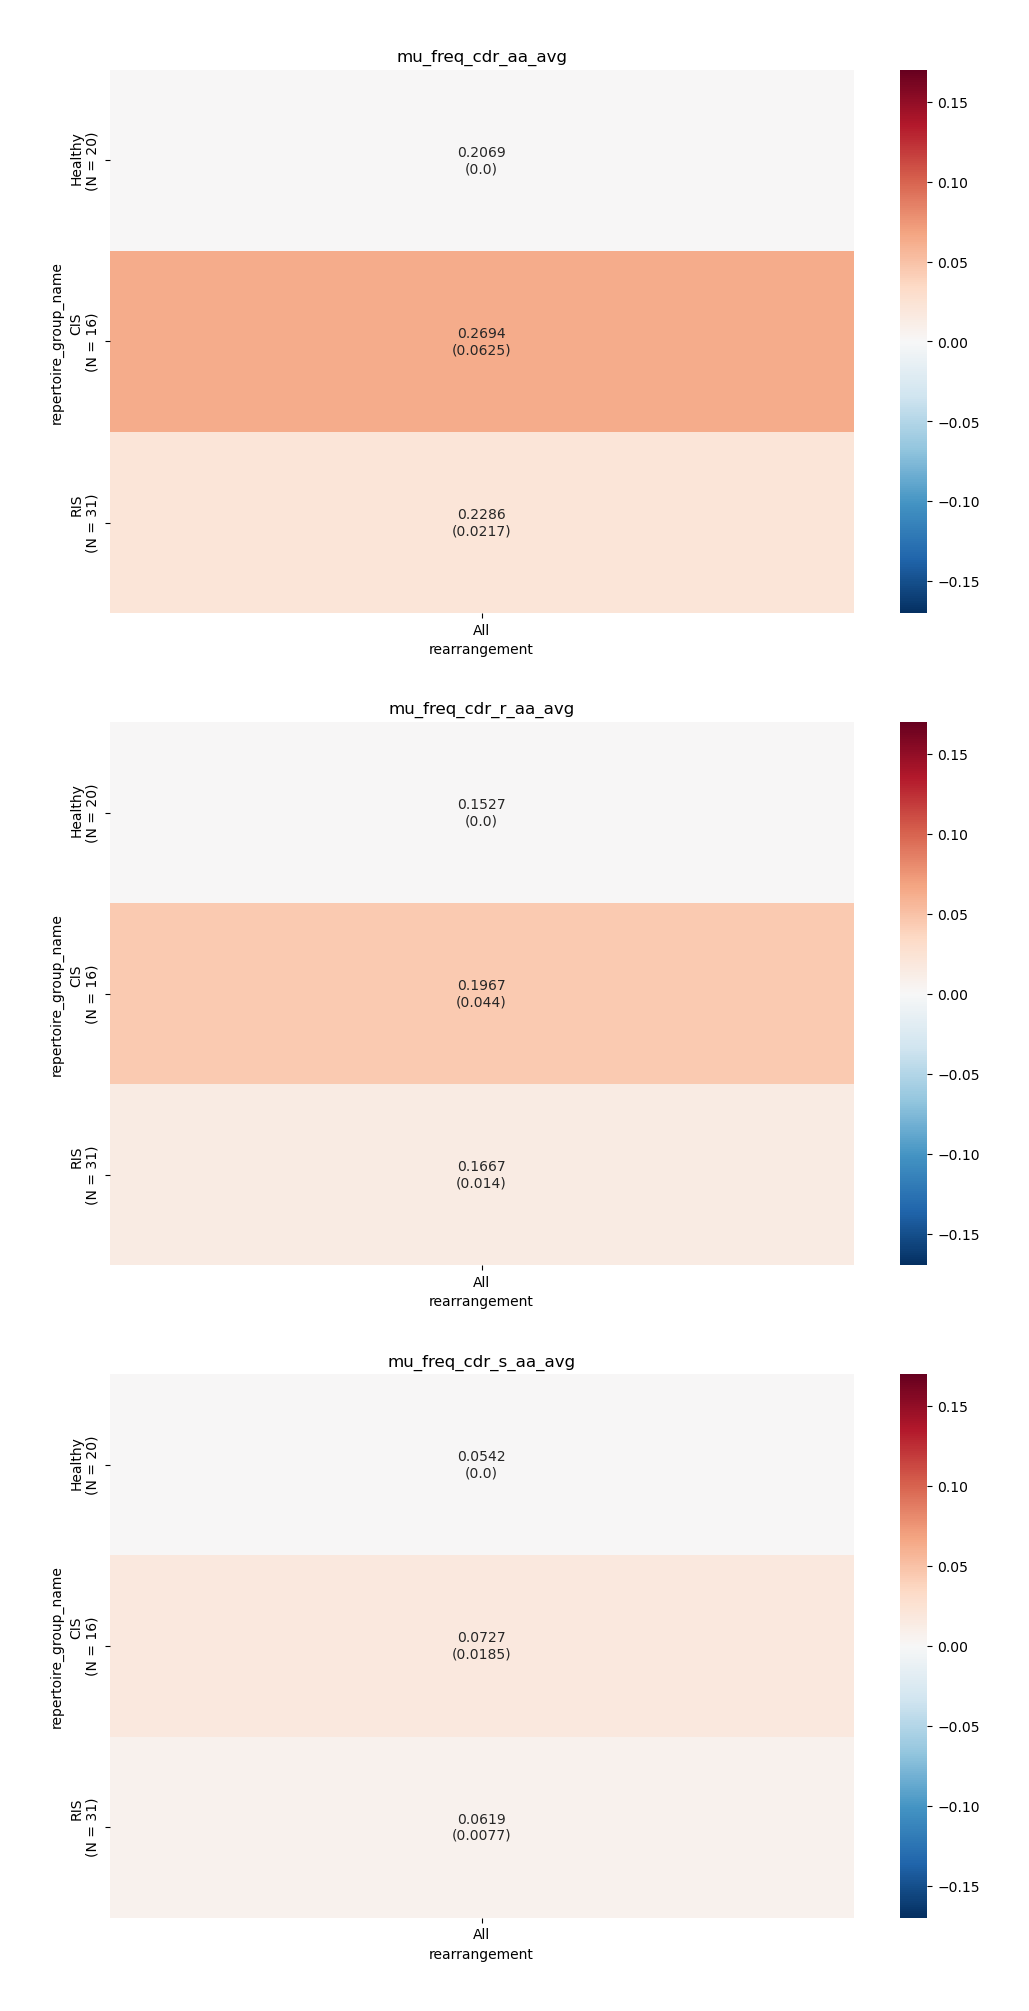

In [56]:
if groups_of_interest:
    idx = groups_of_interest
else:
    idx = list(freq_df['repertoire_group_name'].unique())

value_cols = ['mu_freq_cdr_aa_avg', 'mu_freq_cdr_r_aa_avg', 'mu_freq_cdr_s_aa_avg']
# sns.heatmap(subset)

fig, axes = plt.subplots(3, 1, figsize=(12,24))

for i, value in enumerate(value_cols):
    matrix = freq_df.pivot(
        index="repertoire_group_name",
        columns="rearrangement",
        values=value
    ).reindex(idx)

    # keep only one control group
    # one_control_mat = matrix.drop(matrix.index[0], axis=0)
    one_control_mat = matrix

    # make normalized matrix
    norm_mat = norm_cols(one_control_mat, 'difference')

    # make annotation matrix
    annot_mat = make_annotation_mat(one_control_mat, norm_mat, 4, 4)

    sns.heatmap(
        norm_mat,
        annot=annot_mat,
        fmt='',
        cmap="RdBu_r",
        vmin=-0.17,
        vmax=0.17,
        ax=axes[i]
    )

    yticklabels = [f'{e.get_text()}\n(N = {groups_tuple_repnum_map[e.get_text()]})' for e in  axes[i].get_yticklabels()]
    axes[i].set_yticklabels(yticklabels)
    axes[i].set_title(value)

fig.show()
# ax.set_title('(A)', x=-0.4, fontsize=14, weight='bold')
# ax.set_ylabel('Repertoire Group')
# ax.set_xlabel('Gene Family')

#### Mutation Ratio FWR

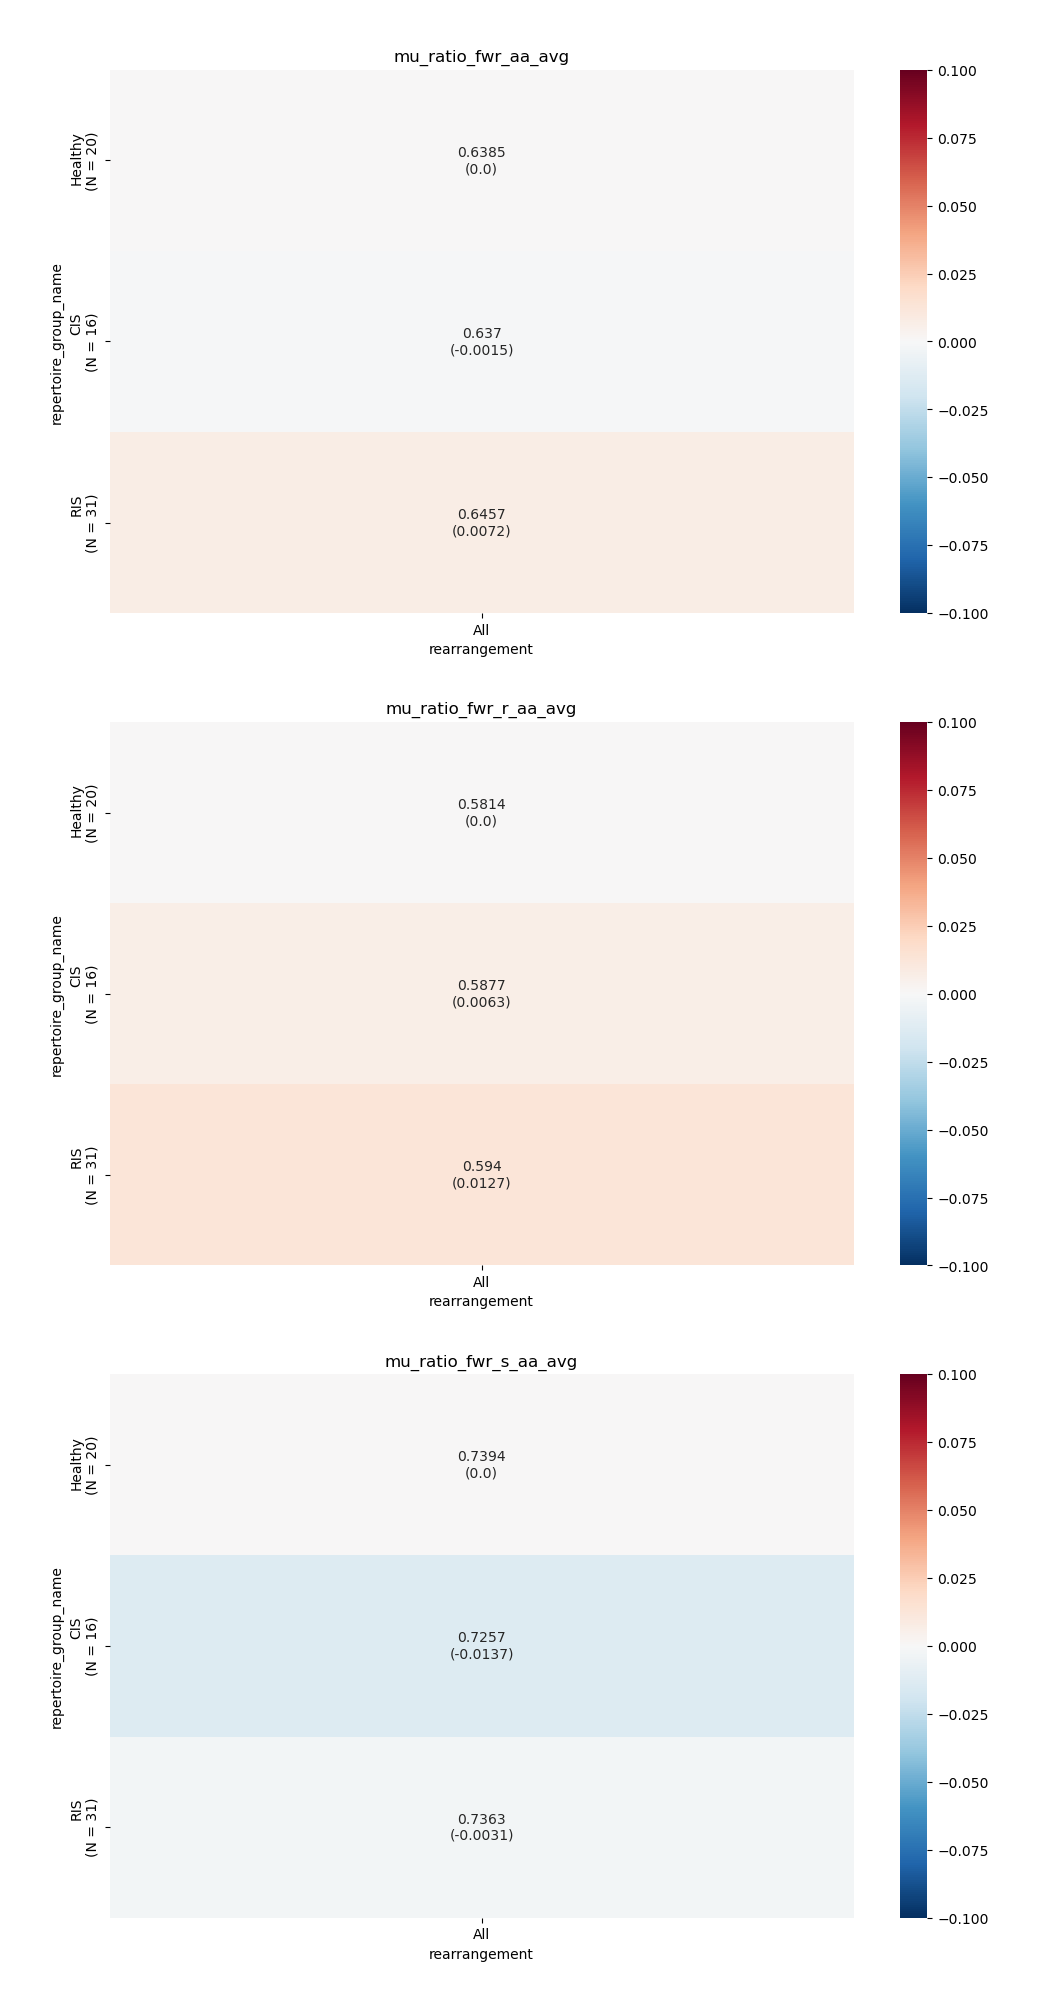

In [57]:
if groups_of_interest:
    idx = groups_of_interest
else:
    idx = list(freq_df['repertoire_group_name'].unique())

value_cols = ['mu_ratio_fwr_aa_avg', 'mu_ratio_fwr_r_aa_avg', 'mu_ratio_fwr_s_aa_avg']
# sns.heatmap(subset)

fig, axes = plt.subplots(3, 1, figsize=(12,24))

for i, value in enumerate(value_cols):
    matrix = ratio_df.pivot(
        index="repertoire_group_name",
        columns="rearrangement",
        values=value
    ).reindex(idx)

    # keep only one control group
    # one_control_mat = matrix.drop(matrix.index[1], axis=0)
    one_control_mat = matrix

    # make normalized matrix
    norm_mat = norm_cols(one_control_mat, 'difference')

    # make annotation matrix
    annot_mat = make_annotation_mat(one_control_mat, norm_mat, 4, 4)

    sns.heatmap(
        norm_mat,
        annot=annot_mat,
        fmt='',
        cmap="RdBu_r",
        vmin=-0.1,
        vmax=0.1,
        ax=axes[i]
    )

    yticklabels = [f'{e.get_text()}\n(N = {groups_tuple_repnum_map[e.get_text()]})' for e in  axes[i].get_yticklabels()]
    axes[i].set_yticklabels(yticklabels)
    axes[i].set_title(value)

fig.show()
# ax.set_title('(A)', x=-0.4, fontsize=14, weight='bold')
# ax.set_ylabel('Repertoire Group')
# ax.set_xlabel('Gene Family')

#### Mutation Ratio CDR

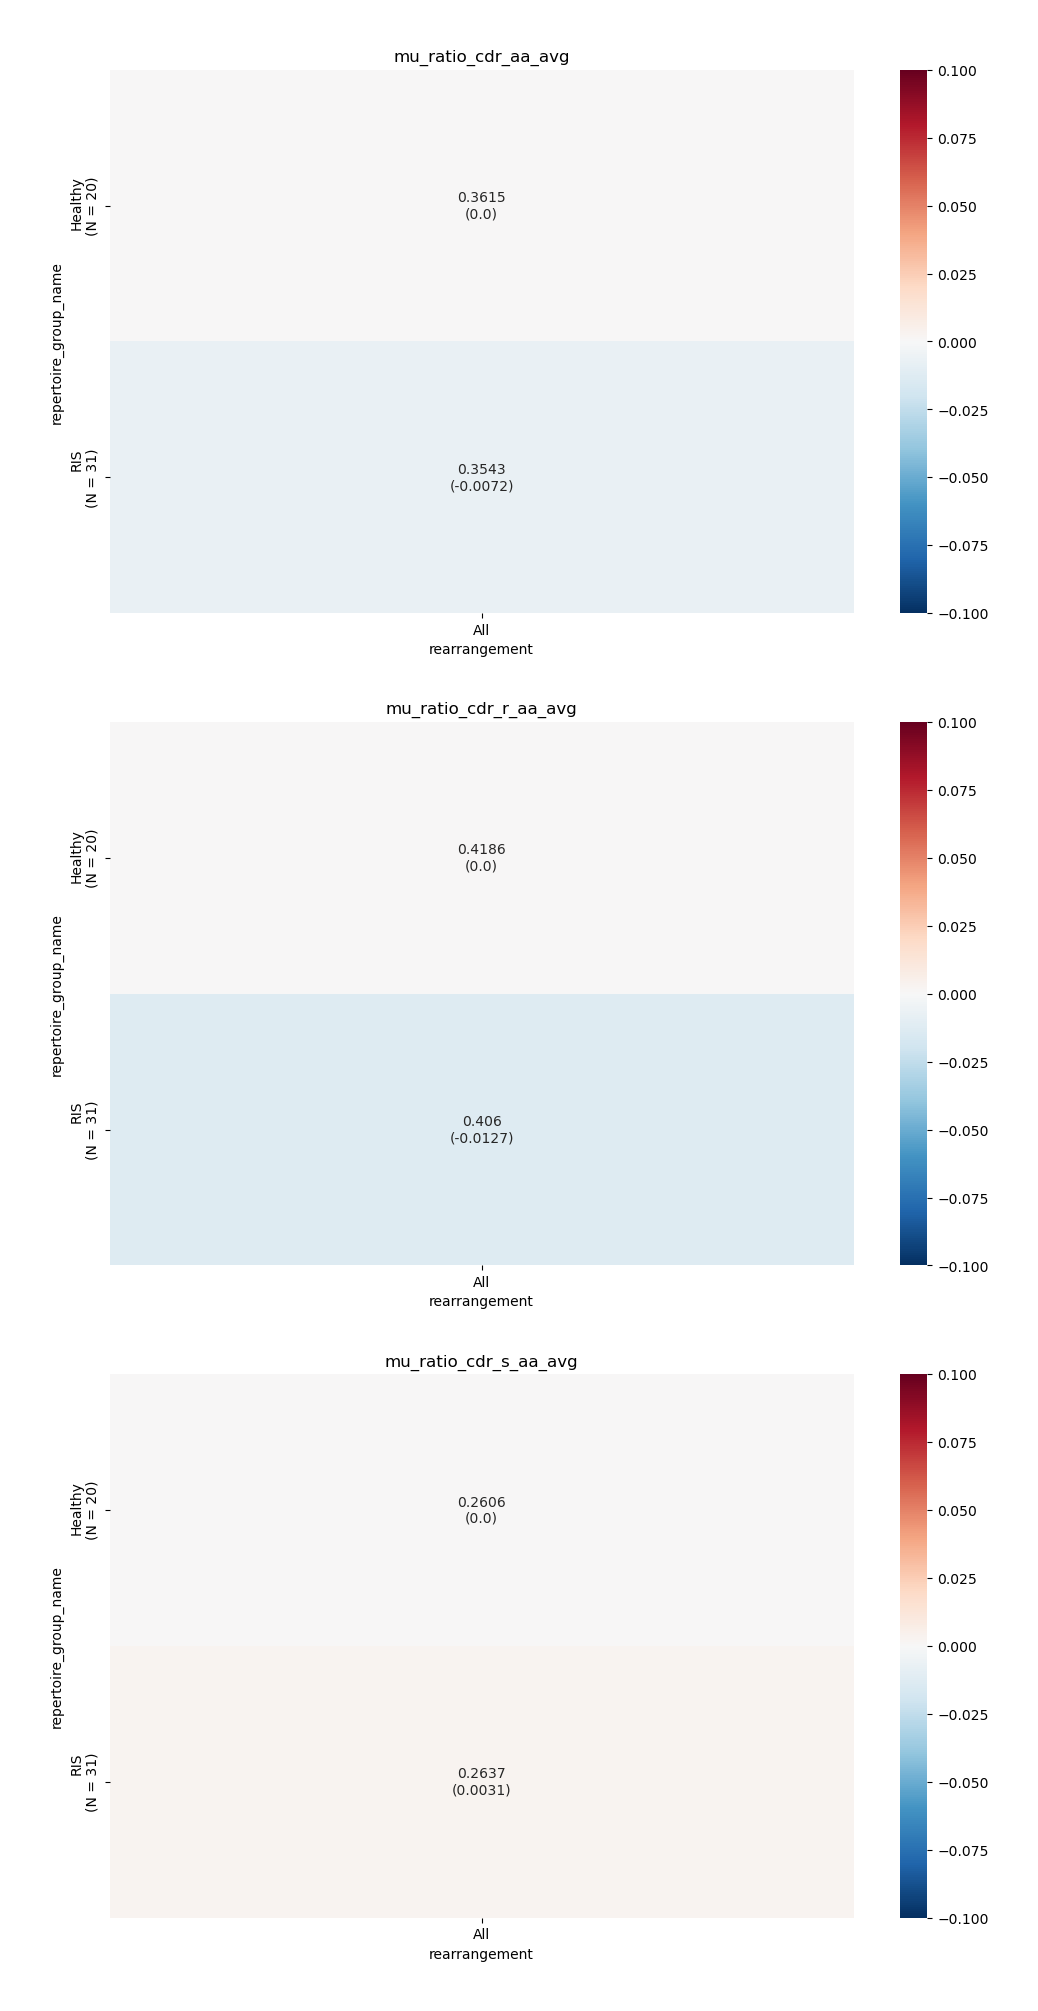

In [58]:
if groups_of_interest:
    idx = groups_of_interest
else:
    idx = list(freq_df['repertoire_group_name'].unique())

value_cols = ['mu_ratio_cdr_aa_avg', 'mu_ratio_cdr_r_aa_avg', 'mu_ratio_cdr_s_aa_avg']
# sns.heatmap(subset)

fig, axes = plt.subplots(3, 1, figsize=(12,24))

for i, value in enumerate(value_cols):
    matrix = ratio_df.pivot(
        index="repertoire_group_name",
        columns="rearrangement",
        values=value
    ).reindex(idx)

    # keep only one control group
    one_control_mat = matrix.drop(matrix.index[1], axis=0)

    # make normalized matrix
    norm_mat = norm_cols(one_control_mat, 'difference')

    # make annotation matrix
    annot_mat = make_annotation_mat(one_control_mat, norm_mat, 4, 4)

    sns.heatmap(
        norm_mat,
        annot=annot_mat,
        fmt='',
        cmap="RdBu_r",
        vmin=-0.1,
        vmax=0.1,
        ax=axes[i]
    )

    yticklabels = [f'{e.get_text()}\n(N = {groups_tuple_repnum_map[e.get_text()]})' for e in  axes[i].get_yticklabels()]
    axes[i].set_yticklabels(yticklabels)
    axes[i].set_title(value)

fig.show()
# ax.set_title('(A)', x=-0.4, fontsize=14, weight='bold')
# ax.set_ylabel('Repertoire Group')
# ax.set_xlabel('Gene Family')

### Tables

#### Mutation RS Ratio FWR

In [59]:
if groups_of_interest:
    idx = groups_of_interest
else:
    idx = list(freq_df['repertoire_group_name'].unique())

# means to view data easily (temp)
matrix = ratio_df.pivot_table(
    index="repertoire_group_name",
    columns="rearrangement",
    values="mu_rsratio_fwr_aa_avg"
).reindex(idx)
matrix

print(tabulate(matrix, tablefmt='heavy_grid', headers=matrix.columns))

┏━━━━━━━━━┳━━━━━━━━━┓
┃         ┃     All ┃
┣━━━━━━━━━╋━━━━━━━━━┫
┃ Healthy ┃ 1.38597 ┃
┣━━━━━━━━━╋━━━━━━━━━┫
┃ CIS     ┃ 1.45838 ┃
┣━━━━━━━━━╋━━━━━━━━━┫
┃ RIS     ┃ 1.41738 ┃
┗━━━━━━━━━┻━━━━━━━━━┛


/tmp/ipykernel_1678556/1032072425.py:7: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  matrix = ratio_df.pivot_table(


#### Mutation RS Ratio CDR

In [60]:
if groups_of_interest:
    idx = groups_of_interest
else:
    idx = list(freq_df['repertoire_group_name'].unique())

matrix = ratio_df.pivot_table(
    index="repertoire_group_name",
    columns="rearrangement",
    values="mu_rsratio_cdr_aa_avg"
).reindex(idx)
matrix

print(tabulate(matrix, tablefmt='heavy_grid', headers=matrix.columns))

┏━━━━━━━━━┳━━━━━━━━━┓
┃         ┃     All ┃
┣━━━━━━━━━╋━━━━━━━━━┫
┃ Healthy ┃ 2.84104 ┃
┣━━━━━━━━━╋━━━━━━━━━┫
┃ CIS     ┃ 2.70794 ┃
┣━━━━━━━━━╋━━━━━━━━━┫
┃ RIS     ┃ 2.71577 ┃
┗━━━━━━━━━┻━━━━━━━━━┛


/tmp/ipykernel_1678556/2592853615.py:6: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  matrix = ratio_df.pivot_table(


#### Mutation Ratio

In [61]:
cols = ['mu_ratio_fwr_aa', 'mu_ratio_cdr_aa', 'mu_ratio_fwr_r_aa', 'mu_ratio_fwr_s_aa', 'mu_ratio_cdr_r_aa', 'mu_ratio_cdr_s_aa', 'mu_rsratio_fwr_aa', 'mu_rsratio_cdr_aa']
true_cols = [[col+'_avg', col+'_std', col+'_N'] for col in cols]
true_cols = [col for true_col in true_cols for col in true_col]

true_cols
df = ratio_df.loc[:,['repertoire_group_name']+true_cols]
df = df.set_index('repertoire_group_name')
if groups_of_interest:
    df = df.reindex(groups_of_interest)

compressed_df = pd.DataFrame(index=df.index, columns=cols)

for col in cols:
    compressed_df.loc[:,col] = df.loc[:,col+'_avg'].astype(float).round(4).astype(str) + \
        ' ± ' + df.loc[:,col+'_std'].astype(float).round(6).astype(str) + \
        '\n' + '(N=' + df.loc[:,col+'_N'].astype(str) + ')'

print(compressed_df.to_markdown())
compressed_df.to_excel('mu_ratio_table.xlsx')

| repertoire_group_name   | mu_ratio_fwr_aa   | mu_ratio_cdr_aa   | mu_ratio_fwr_r_aa   | mu_ratio_fwr_s_aa   | mu_ratio_cdr_r_aa   | mu_ratio_cdr_s_aa   | mu_rsratio_fwr_aa   | mu_rsratio_cdr_aa   |
|:------------------------|:------------------|:------------------|:--------------------|:--------------------|:--------------------|:--------------------|:--------------------|:--------------------|
| Healthy                 | 0.6385 ± 0.021662 | 0.3615 ± 0.021662 | 0.5814 ± 0.031134   | 0.7394 ± 0.011523   | 0.4186 ± 0.031134   | 0.2606 ± 0.011523   | 1.386 ± 0.092835    | 2.841 ± 0.329736    |
|                         | (N=20.0)          | (N=20.0)          | (N=20.0)            | (N=20.0)            | (N=20.0)            | (N=20.0)            | (N=20.0)            | (N=20.0)            |
| CIS                     | 0.637 ± 0.010009  | 0.363 ± 0.010009  | 0.5877 ± 0.01076    | 0.7257 ± 0.009026   | 0.4123 ± 0.01076    | 0.2743 ± 0.009026   | 1.4584 ± 0.062479   | 2.7079 ± 0.127361   |


#### Mutation Frequency

In [62]:
cols = ['mu_freq_fwr_aa', 'mu_freq_cdr_aa', 'mu_freq_fwr_r_aa', 'mu_freq_fwr_s_aa', 'mu_freq_cdr_r_aa', 'mu_freq_cdr_s_aa']
true_cols = [[col+'_avg', col+'_std', col+'_N'] for col in cols]
true_cols = [col for true_col in true_cols for col in true_col]

true_cols
df = freq_df.loc[:,['repertoire_group_name']+true_cols]
df = df.set_index('repertoire_group_name')
if groups_of_interest:
    df = df.reindex(groups_of_interest)

compressed_df = pd.DataFrame(index=df.index, columns=cols)

for col in cols:
    compressed_df.loc[:,col] = df.loc[:,col+'_avg'].astype(float).round(4).astype(str) + \
        ' ± ' + df.loc[:,col+'_std'].astype(float).round(6).astype(str) + \
        '\n' + '(N=' + df.loc[:,col+'_N'].astype(str) + ')'

# print(compressed_df.to_markdown())
print(tabulate(compressed_df, tablefmt='heavy_grid', headers=['Group Name']+cols))
compressed_df.to_excel('mu_freq_table.xlsx')

┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Group Name   ┃ mu_freq_fwr_aa    ┃ mu_freq_cdr_aa    ┃ mu_freq_fwr_r_aa   ┃ mu_freq_fwr_s_aa   ┃ mu_freq_cdr_r_aa   ┃ mu_freq_cdr_s_aa   ┃
┣━━━━━━━━━━━━━━╋━━━━━━━━━━━━━━━━━━━╋━━━━━━━━━━━━━━━━━━━╋━━━━━━━━━━━━━━━━━━━━╋━━━━━━━━━━━━━━━━━━━━╋━━━━━━━━━━━━━━━━━━━━╋━━━━━━━━━━━━━━━━━━━━┫
┃ Healthy      ┃ 0.1005 ± 0.03786  ┃ 0.2069 ± 0.077378 ┃ 0.0585 ± 0.022309  ┃ 0.042 ± 0.015716   ┃ 0.1527 ± 0.057375  ┃ 0.0542 ± 0.020441  ┃
┃              ┃ (N=20.0)          ┃ (N=20.0)          ┃ (N=20.0)           ┃ (N=20.0)           ┃ (N=20.0)           ┃ (N=20.0)           ┃
┣━━━━━━━━━━━━━━╋━━━━━━━━━━━━━━━━━━━╋━━━━━━━━━━━━━━━━━━━╋━━━━━━━━━━━━━━━━━━━━╋━━━━━━━━━━━━━━━━━━━━╋━━━━━━━━━━━━━━━━━━━━╋━━━━━━━━━━━━━━━━━━━━┫
┃ CIS          ┃ 0.13 ± 0.016323   ┃ 0.2694 ± 0.033814 ┃ 0.0771 ± 0.009917  ┃ 0.0529 ± 0.006624  ┃ 0.1967 ± 0.025351  ┃ 0.0727 ± 0.008871  ┃
┃            

#### Mutation Ratio/RS Ratio FWR/CDR

In [63]:
cols = ['mu_ratio_fwr_aa', 'mu_ratio_cdr_aa', 'mu_ratio_fwr_r_aa', 'mu_ratio_fwr_s_aa', 'mu_ratio_cdr_r_aa', 'mu_ratio_cdr_s_aa']
out_ratio_df = ratio_df.loc[:,['repertoire_group_name']+[col+'_avg' for col in cols]]
out_ratio_df = out_ratio_df.set_index('repertoire_group_name')
out_ratio_df = out_ratio_df.rename(columns={col:'_'.join(col.split('_')[:-1]) for col in out_ratio_df.columns})
temp_ratio_df = ratio_df.set_index('repertoire_group_name')

for col in out_ratio_df.columns:
    out_ratio_df[col] = out_ratio_df[col].round(5).astype(str) + ' ± ' + temp_ratio_df[col+'_std'].round(5).astype(str) +'\n(N='+temp_ratio_df[col+'_N'].astype(str)+')'

print(tabulate(out_ratio_df, tablefmt='heavy_grid', headers=['Group Name']+cols))

┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ Group Name   ┃ mu_ratio_fwr_aa   ┃ mu_ratio_cdr_aa   ┃ mu_ratio_fwr_r_aa   ┃ mu_ratio_fwr_s_aa   ┃ mu_ratio_cdr_r_aa   ┃ mu_ratio_cdr_s_aa   ┃
┣━━━━━━━━━━━━━━╋━━━━━━━━━━━━━━━━━━━╋━━━━━━━━━━━━━━━━━━━╋━━━━━━━━━━━━━━━━━━━━━╋━━━━━━━━━━━━━━━━━━━━━╋━━━━━━━━━━━━━━━━━━━━━╋━━━━━━━━━━━━━━━━━━━━━┫
┃ Healthy      ┃ 0.63848 ± 0.02166 ┃ 0.36152 ± 0.02166 ┃ 0.58138 ± 0.03113   ┃ 0.73936 ± 0.01152   ┃ 0.41862 ± 0.03113   ┃ 0.26064 ± 0.01152   ┃
┃              ┃ (N=20.0)          ┃ (N=20.0)          ┃ (N=20.0)            ┃ (N=20.0)            ┃ (N=20.0)            ┃ (N=20.0)            ┃
┣━━━━━━━━━━━━━━╋━━━━━━━━━━━━━━━━━━━╋━━━━━━━━━━━━━━━━━━━╋━━━━━━━━━━━━━━━━━━━━━╋━━━━━━━━━━━━━━━━━━━━━╋━━━━━━━━━━━━━━━━━━━━━╋━━━━━━━━━━━━━━━━━━━━━┫
┃ CIS          ┃ 0.63699 ± 0.01001 ┃ 0.36301 ± 0.01001 ┃ 0.58769 ± 0.01076   ┃ 0.72568 ± 0.00903   ┃ 0.41231 ± 0.01076   ┃ 0.27432

### Bar Graphs

#### Mutation Ratio FWR

(<Figure size 1600x800 with 1 Axes>,
 <Axes: title={'center': 'mu_ratio_fwr'}, xlabel='repertoire_group_name', ylabel='mu_ratio_fwr_avg'>)

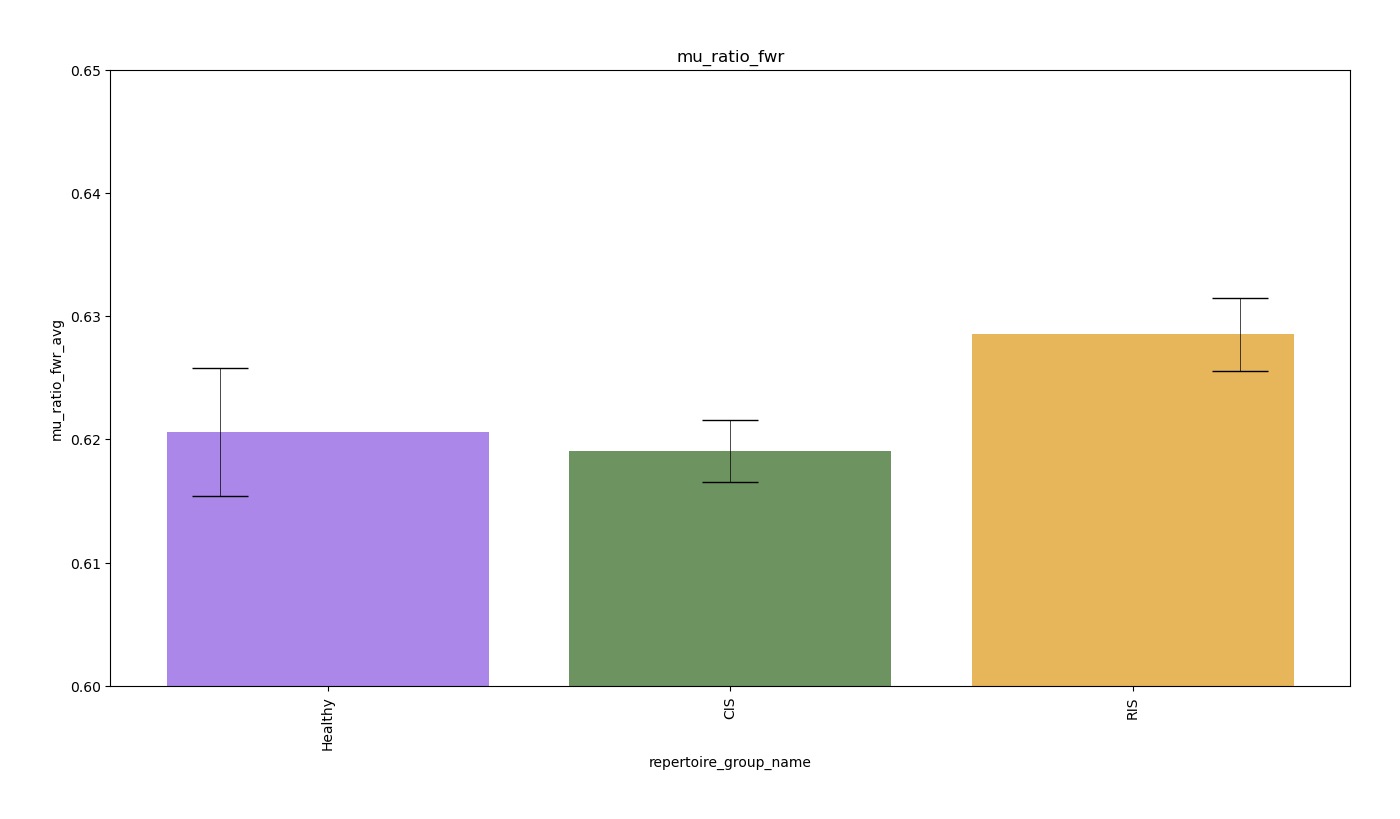

In [64]:
gr.plot_ratio(
    ratio_df,
    region='mu_ratio_fwr',
    errorbar='se',
    ylim=(0.6,0.65),
    title='mu_ratio_fwr',
    palette=cond_cmap
)

#### Mutation Ratio CDR

(<Figure size 1600x800 with 1 Axes>,
 <Axes: title={'center': 'mu_ratio_cdr'}, xlabel='repertoire_group_name', ylabel='mu_ratio_cdr_avg'>)

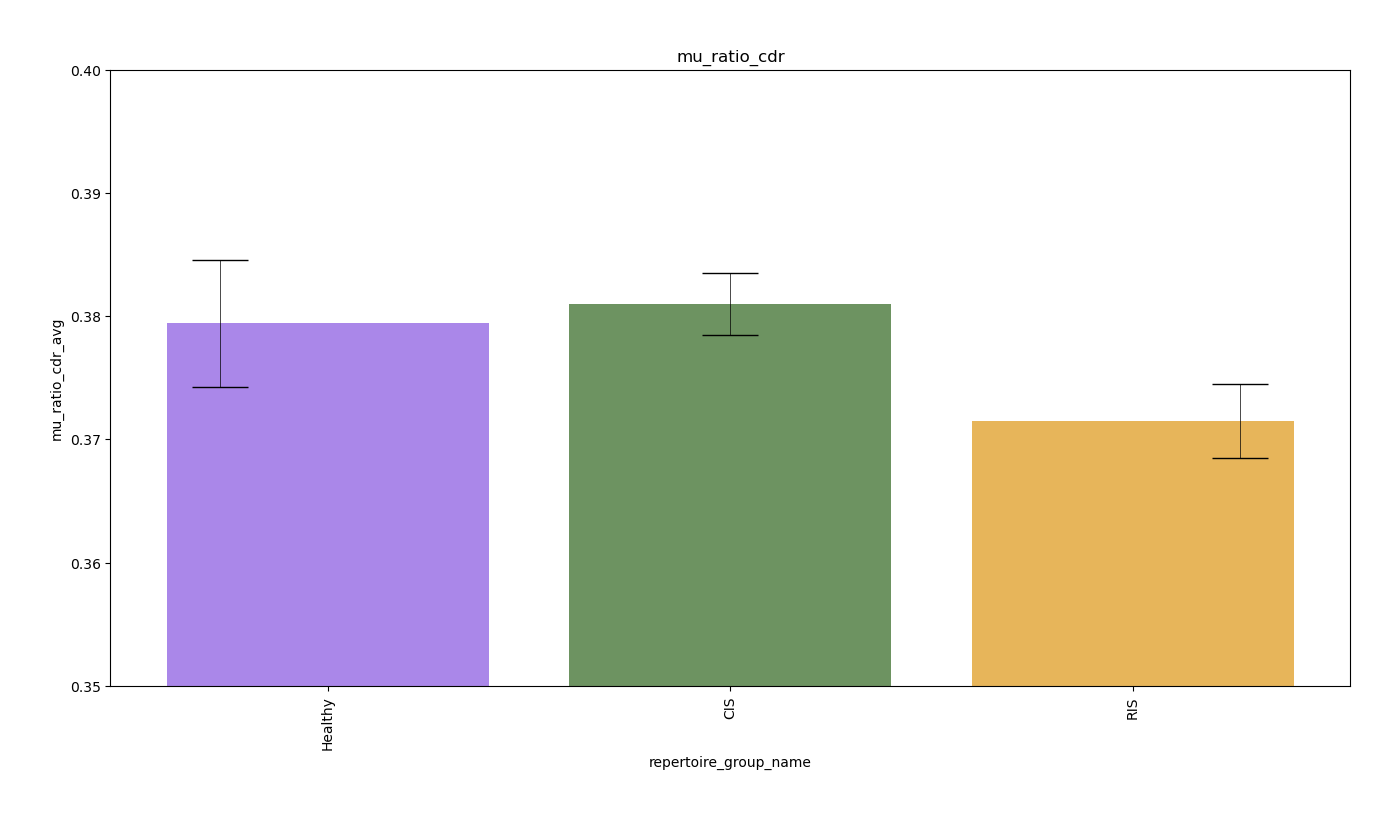

In [65]:
gr.plot_ratio(
    ratio_df,
    region='mu_ratio_cdr',
    errorbar='se',
    ylim=(0.35,0.4),
    title='mu_ratio_cdr',
    palette=cond_cmap
)

#### Mutation RS Ratio FWR

(<Figure size 1600x800 with 1 Axes>,
 <Axes: title={'center': 'mu_rsratio_fwr'}, xlabel='repertoire_group_name', ylabel='mu_rsratio_fwr_avg'>)

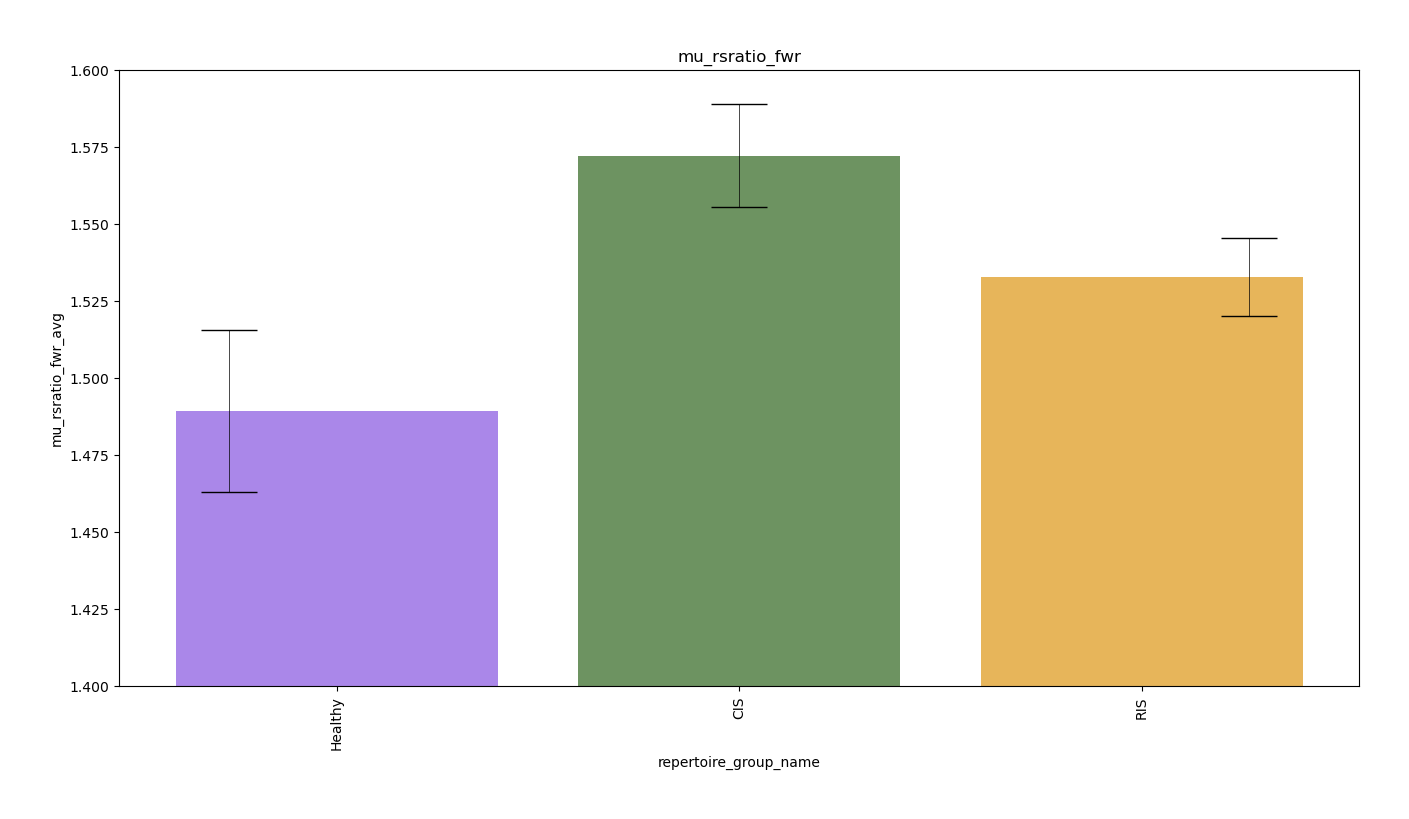

In [66]:
gr.plot_ratio(
    ratio_df,
    region='mu_rsratio_fwr',
    errorbar='se',
    ylim=(1.4,1.6),
    title='mu_rsratio_fwr',
    palette=cond_cmap
)

#### Mutation RS Ratio CDR

(<Figure size 1600x800 with 1 Axes>,
 <Axes: title={'center': 'mu_rsratio_cdr'}, xlabel='repertoire_group_name', ylabel='mu_rsratio_cdr_avg'>)

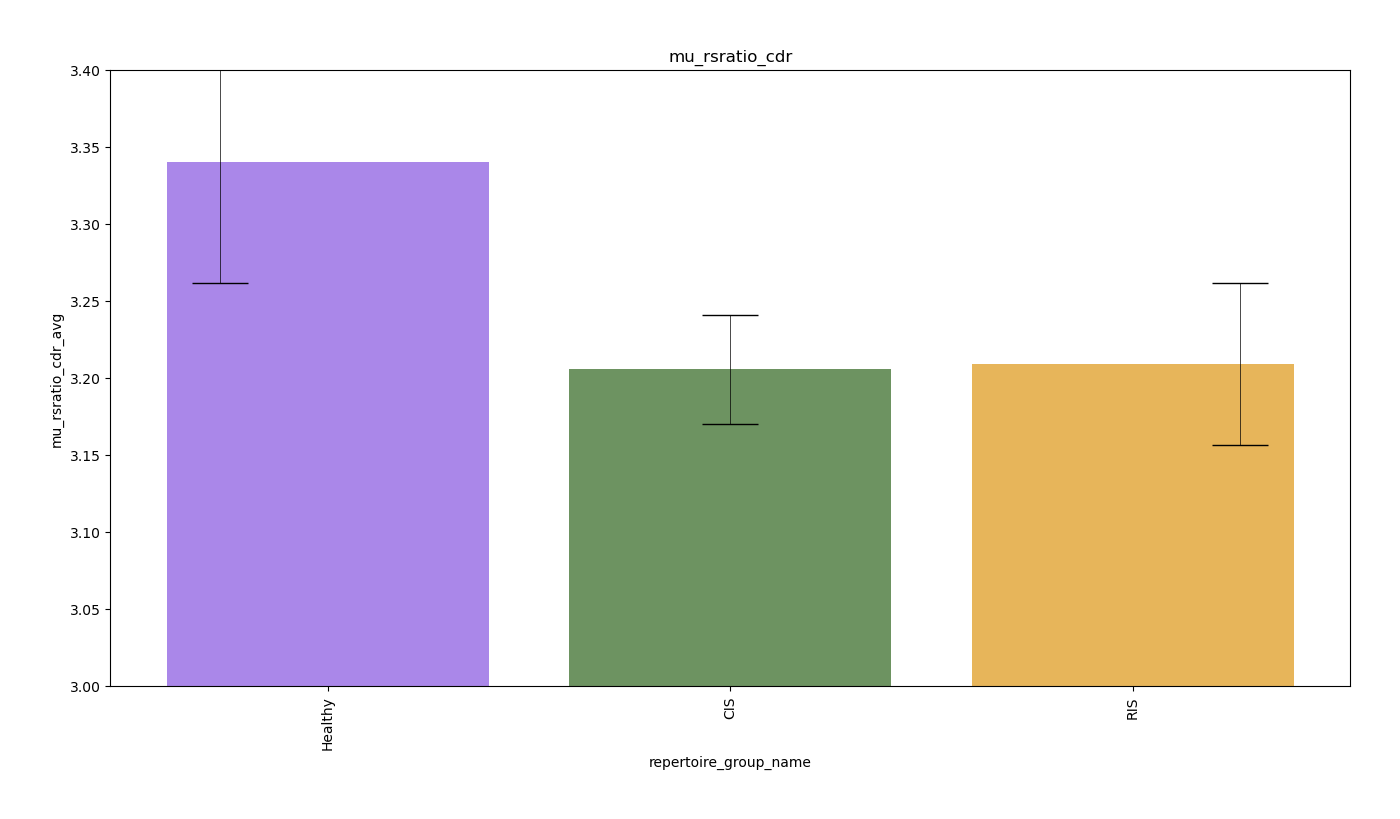

In [67]:
gr.plot_ratio(
    ratio_df,
    region='mu_rsratio_cdr',
    errorbar='se',
    ylim=(3.0, 3.4),
    title='mu_rsratio_cdr',
    palette=cond_cmap
)

## AA Sharing

In [68]:
# plot_type = 'between' if len(groups) == 2 else 'within'
plot_type = 'between'

sharing = 'cdr3_aa_sharing'
processing_stage = 'repertoire.shared.matrix'
# processing_stage = 'group.summary_comparison'

similarity_metric = 'a_in_b' #jaccard, simpson_coefficient, a_in_b, b_in_a
# similarity_metric = 'b_in_a' #jaccard, simpson_coefficient, a_in_b, b_in_a
percentage = True

# setup to compare against healthy control (diag_hi_groups[0])
for control_group_name in control_group_names:
    for i, group in enumerate([group for group in groups_tuple if group[1] in hue_order]):
        if group[1] == control_group_name or control_group_name is None:
            control = group
            break

    for i, group in enumerate([group for group in groups_tuple if group[1] in hue_order]):
        if group == control:
            continue
        matrix = br.load_shared_cdr3_aa_data(
            repcalc_dir,
            repertoire_groups, 
            sample_info_df, 
            groups=[control, group], 
            percentage=percentage,
            similarity_metric=similarity_metric,
            sharing=sharing,
            processing_stage=processing_stage,
            plot_type=plot_type
        )
        matrix = matrix.sort_index().sort_index(axis=1)
        fig, ax = gr.plot_cdr3_aa_sharing_heatmap(matrix, cmap = 'viridis', figsize = (36, 30))
        plt.title(f"Heatmap of {sharing} {plot_type} group")
        plt.tight_layout()


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/md0/Projects/MonsonLab/RIS/vdjserver/78808056-1d0d-455d-8845-65945c10f336-007/repertoire.shared.matrix.cdr3_aa_sharing.tsv'

## Sequence Count

In [69]:
df = br.load_cdr3_sequences_each_repertoire(
    repcalc_dir=repcalc_dir,
    repertoire_id=data['Repertoire'][0]['repertoire_id'],
    sharing='cdr3_aa_sharing',
    processing_stage='repertoire'
)

fig, ax = gr.plot_cdr3_sequence_count(
    df=df,
    abundance=True,
    top_n=20,
    figsize=(16,8)
)

fig.show()

PermissionError: [Errno 13] Permission denied: '/mnt/md0/Projects/MonsonLab/RIS/vdjserver/78808056-1d0d-455d-8845-65945c10f336-007/04d7b000-246b-423c-a681-bde576c5b3fb.repertoire.cdr3_aa_sharing.tsv'

## Unique Number of Sequences

In [70]:
sharing='cdr3_aa_sharing'
processing_stage='repertoire'

# setup to compare against healthy control (diag_hi_groups[0])
for control_group in control_group_names:
    if control_group == None:
        control = groups_tuple[0]
    else:
        for i, group in enumerate([group for group in groups_tuple if group[1] in hue_order]):
            if group[1] == control_group:
                control = group
            break

    for i, group in enumerate([group for group in groups_tuple if group[1] in hue_order]):
        if group == control:
            continue

        df = br.load_unique_cdr3_sequence_numbers(
            repcalc_dir,
            repertoire_groups,
            groups=[control, group],
            sample_info_df=sample_info_df,
            sharing=sharing,
            processing_stage=processing_stage
        )
        fig, axes = gr.plot_unique_number_of_cdr3(
            df,
            # palette=cond_cmap,
            # figsize=(12, 6)
        )
        add_N_to_legend(axes[1], groups_tuple)
        condition_counts = {e[1] : len(e[2]) for e in groups_tuple}
        fig.suptitle(f"Unique number of CDR3 for {' vs '.join([control[1]+f' (N={condition_counts[control[1]]})', group[1]+f' (N={condition_counts[group[1]]})'])}")
        fig.tight_layout()

        fig.show()

        # figname = f'Figures/unique_number_of_cdr3_{'_'.join(group_names)}.png'
        # plt.savefig(figname, bbox_inches = 'tight', dpi = 300)

PermissionError: [Errno 13] Permission denied: '/mnt/md0/Projects/MonsonLab/RIS/vdjserver/78808056-1d0d-455d-8845-65945c10f336-007/a7b4e6f6-6bcf-4d3c-b970-e84ede32331a.repertoire.cdr3_aa_sharing.tsv'